# 06 - Selección del mejor modelo con AutoML

### Por: Carlos Javier Palacios Sanchez

### Fecha: 21/08/2026

### Descripción

**Requerimiento.** Seleccionar el mejor modelo que resuelva el problema de clasificación y
supere al modelo base de la etapa anterior, usando **herramientas de AutoML**
([AutoGluon](https://auto.gluon.ai/), [PyCaret](https://pycaret.org/),
[TabPFN](https://github.com/PriorLabs/TabPFN), [MLJar](https://mljar.com/automl/),
[FLAML](https://microsoft.github.io/FLAML/)). El trabajo se hace en una rama nueva
siguiendo [Gitflow](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/).

**Proyecto:** predicción de enfermedad coronaria a partir del conjunto de datos de
cardiología (`notebooks/1-data/corazon.csv`).

**Punto de partida.** La etapa 5 dejó dos números que gobiernan este notebook: el modelo
base oficial es la **heurística clínica** con **ROC-AUC 0.848 ± 0.055** en validación
cruzada, y la recomendación explícita de fijar el criterio de éxito en **ROC-AUC > 0.90**,
no en superar al `DummyClassifier`.

---

## 0. Qué se hace en este notebook

| # | Punto del requerimiento | Sección |
|---|---|---|
| 1 | Utilizar herramientas de AutoML para la selección del mejor modelo | 6, 7, 9 y 10 |
| 2 | Análisis de *learning curve* | 15 |
| 3 | Analizar *overfitting* y *underfitting* | 16 |
| 4 | Gráficas de escalabilidad (tiempo de entrenamiento y score) | 8 y 17 |
| 5 | Almacenar el pipeline de preprocesamiento + modelo | 21 |
| 6 | Interpretar los resultados | 20 y 22 |
| 7 | Análisis de los resultados | 23 |
| 8 | Definir recomendaciones | 25 |

Y tres secciones que el requerimiento no pide pero sin las cuales las anteriores no se
pueden defender: la **validación cruzada honesta** (sección 12), la medición del
**optimismo del propio AutoML** (sección 13) y las **pruebas estadísticas** de comparación
(sección 14).

> **Resumen ejecutivo.** Tres motores de búsqueda independientes convergen al mismo lugar:
> una **regresión logística con regularización L2 fuerte**. El mejor modelo alcanza
> **ROC-AUC 0.892 ± 0.039** en validación cruzada — mejor que el modelo base, pero la
> diferencia **no es estadísticamente significativa** y **no llega al objetivo de 0.90**
> fijado en la etapa 5. El notebook documenta por qué ése es el resultado honesto y qué
> hacer con él.

## 1. Configuración e importación de librerías

In [1]:
import json
import shutil
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import sklearn
from flaml import AutoML
from lightgbm import LGBMClassifier
from scipy import stats
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibrationDisplay
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
    validation_curve,
)
from sklearn.pipeline import Pipeline
from supervised.automl import AutoML as MljarAutoML
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

SEMILLA = 42
PROPORCION_TEST = 0.2

print(f"python       : {sys.version.split()[0]}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")

/home/claude/repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python       : 3.12.3
scikit-learn : 1.9.0
pandas       : 3.0.5
numpy        : 2.5.2


### Rutas del proyecto

Se resuelve la raíz del repositorio buscando `pyproject.toml` hacia arriba, para que el
notebook funcione igual si se ejecuta desde su carpeta o desde la raíz del proyecto.

In [2]:
RUTA_RAIZ = Path.cwd().resolve()
while not (RUTA_RAIZ / "pyproject.toml").exists() and RUTA_RAIZ.parent != RUTA_RAIZ:
    RUTA_RAIZ = RUTA_RAIZ.parent

RUTA_CRUDOS = RUTA_RAIZ / "notebooks" / "1-data" / "corazon.csv"
RUTA_MODELOS = RUTA_RAIZ / "models"
RUTA_REPORTES = RUTA_RAIZ / "data" / "08_reporting"
RUTA_AUTOML = RUTA_RAIZ / "data" / "07_model_output"

for carpeta in (RUTA_MODELOS, RUTA_REPORTES, RUTA_AUTOML):
    carpeta.mkdir(parents=True, exist_ok=True)

if str(RUTA_RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RUTA_RAIZ / "src"))

print(f"Raíz del proyecto : {RUTA_RAIZ}")
print(f"Datos crudos      : {RUTA_CRUDOS.relative_to(RUTA_RAIZ)}")

Raíz del proyecto : /home/claude/repo
Datos crudos      : notebooks/1-data/corazon.csv


## 2. Reutilización del pipeline de preprocesamiento

Se importa el mismo módulo que usaron las etapas 4 y 5. No se copia ni se reescribe nada:
si el pipeline cambia, este notebook cambia con él.

Los doce atributos de entrada son los que sobrevivieron a la selección de la etapa 4
(se descartó `fbs`, cuya información mutua con el *target* es prácticamente cero).

In [3]:
from pipelines.feature_pipeline import (
    ATRIBUTOS_DERIVADOS,
    OBJETIVO,
    construir_pipeline_features,
    limpiar_datos,
)

ATRIBUTOS_SELECCIONADOS = [
    "age",
    "sex",
    "chest_pain",
    "rest_bp",
    "chol",
    "rest_ecg",
    "max_hr",
    "exang",
    "old_peak",
    "slope",
    "ca",
    "thal",
]

print(f"Atributos de entrada ({len(ATRIBUTOS_SELECCIONADOS)}): {ATRIBUTOS_SELECCIONADOS}")
print(f"Atributos derivados  ({len(ATRIBUTOS_DERIVADOS)}): {ATRIBUTOS_DERIVADOS}")
construir_pipeline_features(ATRIBUTOS_SELECCIONADOS)

Atributos de entrada (12): ['age', 'sex', 'chest_pain', 'rest_bp', 'chol', 'rest_ecg', 'max_hr', 'exang', 'old_peak', 'slope', 'ca', 'thal']
Atributos derivados  (7): ['fc_maxima_teorica', 'reserva_cardiaca', 'chol_rel_edad', 'carga_presion', 'log_old_peak', 'sqrt_chol', 'st_deprimido']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('atributos_derivados', ...), ('preprocesamiento', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function agr...x7f25b1b4a200>
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",<function nom...x7f25b1b4a5c0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"kw

## 3. Carga y limpieza de los datos

`limpiar_datos` es determinista —no aprende ningún parámetro de los datos— por lo que
puede aplicarse antes de la partición sin producir fuga. Normaliza el texto, invalida los
valores fuera de dominio, descarta las filas sin *target* y elimina los duplicados exactos
y parciales que la etapa 2 documentó (el archivo crudo tiene 3 030 filas para unos 300
pacientes reales).

In [4]:
datos_crudos = pd.read_csv(RUTA_CRUDOS, dtype=str, keep_default_na=True)
datos_limpios = limpiar_datos(datos_crudos)

print(f"Crudos  : {datos_crudos.shape[0]:>5,} filas x {datos_crudos.shape[1]} columnas")
print(f"Limpios : {datos_limpios.shape[0]:>5,} filas x {datos_limpios.shape[1]} columnas")

distribucion = datos_limpios[OBJETIVO].value_counts().sort_index()
proporcion = datos_limpios[OBJETIVO].value_counts(normalize=True).sort_index()
print("\nDistribución del target (0 = sano, 1 = enfermedad):")
for clase in distribucion.index:
    print(f"  {clase} -> {distribucion[clase]:>3} pacientes ({proporcion[clase]:.1%})")

Crudos  : 3,030 filas x 14 columnas
Limpios :   303 filas x 14 columnas

Distribución del target (0 = sano, 1 = enfermedad):
  0 -> 164 pacientes (54.1%)
  1 -> 139 pacientes (45.9%)


## 4. División *train* / *test*

Se usa **exactamente la misma partición de las etapas 4 y 5**: 80 / 20, estratificada y con
`random_state=42`. Es lo que permite comparar el ROC-AUC de este notebook con el 0.848 del
modelo base sin que la diferencia se explique por un reparto distinto de los pacientes.

El conjunto de *test* se aparta aquí y **no se vuelve a tocar hasta la sección 19**. Nada
de lo que hace el AutoML —búsqueda, selección, comparación— lo ve.

In [5]:
X = datos_limpios[ATRIBUTOS_SELECCIONADOS]
y = datos_limpios[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, stratify=y, random_state=SEMILLA
)

resumen_particion = pd.DataFrame(
    {
        "n_pacientes": [len(y_train), len(y_test), len(y)],
        "n_enfermos": [int(y_train.sum()), int(y_test.sum()), int(y.sum())],
        "prevalencia": [y_train.mean(), y_test.mean(), y.mean()],
    },
    index=["train", "test", "total"],
).round(4)
resumen_particion

,n_pacientes,n_enfermos,prevalencia
train,242,111,0.4587
test,61,28,0.4590
total,303,139,0.4587


## 5. Métricas y protocolo de evaluación

Se reutilizan las once métricas de la etapa 5, por la misma razón: el problema tiene
**costo asimétrico**. Un falso negativo es un paciente con enfermedad coronaria que se va a
casa sin estudio; un falso positivo es una prueba confirmatoria de más. Por eso se optimiza
y se reporta **ROC-AUC** (ordenamiento independiente del umbral), acompañado de exactitud
balanceada, sensibilidad, F2 y MCC.

El protocolo de comparación es `RepeatedStratifiedKFold(5 x 6) = 30 evaluaciones`,
idéntico al de la etapa 5.

In [6]:
def especificidad(y_verdadero, y_predicho) -> float:
    """Proporción de pacientes sanos correctamente identificados como sanos."""
    return recall_score(y_verdadero, y_predicho, pos_label=0, zero_division=0)


METRICAS = {
    "exactitud": make_scorer(accuracy_score),
    "exactitud_balanceada": make_scorer(balanced_accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "sensibilidad": make_scorer(recall_score, zero_division=0),
    "especificidad": make_scorer(especificidad),
    "f1": make_scorer(fbeta_score, beta=1, zero_division=0),
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
    "pr_auc": make_scorer(average_precision_score, response_method="predict_proba"),
    "mcc": make_scorer(matthews_corrcoef),
    "brier": make_scorer(
        brier_score_loss, response_method="predict_proba", greater_is_better=False
    ),
}

VALIDACION = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=SEMILLA)
VALIDACION_CURVA = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)

METRICA_OBJETIVO = "roc_auc"
AUC_MODELO_BASE = 0.8482  # etapa 5: heurística clínica
print(f"{len(METRICAS)} métricas | {VALIDACION.get_n_splits()} evaluaciones por modelo")

11 métricas | 30 evaluaciones por modelo


## 6. Qué herramienta de AutoML usar, y por qué

El requerimiento nombra cinco herramientas. No son intercambiables: cada una asume un
tamaño de problema y un tipo de despliegue distintos. Con **242 pacientes de entrenamiento
y 42 atributos procesados**, el criterio de selección no es "cuál gana en Kaggle" sino
**cuál produce un artefacto que se pueda auditar, versionar y serializar** dentro del
pipeline que ya tiene el proyecto.

| Herramienta | Qué hace | Encaja aquí |
|---|---|---|
| **FLAML** | Búsqueda de hiperparámetros con coste (*CFO* / *BlendSearch*) sobre estimadores de scikit-learn, LightGBM, XGBoost y CatBoost | **Sí.** Devuelve un estimador estándar de scikit-learn, así que entra tal cual en el `Pipeline` del proyecto y se serializa con `joblib` |
| **MLJar** | Explora familias completas, genera *golden features*, apila y ensambla | **Sí, como segunda opinión.** Su valor aquí es contrastar el veredicto de FLAML con una estrategia de búsqueda distinta |
| **TabPFN** | *Transformer* preentrenado que clasifica tablas pequeñas sin entrenar | **Conceptualmente ideal** (está diseñado para n < 10 000), pero descarga pesos desde un repositorio restringido de HuggingFace. Se documenta en la sección 9 |
| **AutoGluon** | Apilamiento multicapa con *bagging*; suele ganar en tablas grandes | **No.** Su ventaja aparece con decenas de miles de filas; con 242 pacientes el apilamiento multicapa sobreajusta y el artefacto resultante es una carpeta, no un estimador |
| **PyCaret** | Capa de alto nivel con su propio preprocesamiento | **No.** Duplicaría el pipeline de la etapa 4 en lugar de reutilizarlo, que es justo lo que este proyecto evita |

**Decisión: FLAML como motor principal, MLJar como verificación independiente y TabPFN
documentado.** Los tres se aplican **sobre la matriz que produce el pipeline de la etapa
4**, no sobre los datos crudos: el AutoML elige el modelo, no el preprocesamiento.

In [7]:
pipeline_features = construir_pipeline_features(ATRIBUTOS_SELECCIONADOS)
X_train_proc = pipeline_features.fit_transform(X_train, y_train)
X_test_proc = pipeline_features.transform(X_test)

print(f"Matriz de entrenamiento procesada: {X_train_proc.shape}")
print(f"Matriz de prueba procesada       : {X_test_proc.shape}")
X_train_proc.head(3)

Matriz de entrenamiento procesada: (242, 42)
Matriz de prueba procesada       : (61, 42)


,continuas__age,continuas__rest_bp,continuas__chol,continuas__max_hr,continuas__old_peak,continuas__fc_maxima_teorica,continuas__reserva_cardiaca,continuas__chol_rel_edad,continuas__carga_presion,continuas__log_old_peak,...,nominales__rest_ecg_left ventricular hypertrophy,nominales__rest_ecg_normal,nominales__rest_ecg_infrequent_sklearn,nominales__thal_fixed,nominales__thal_normal,nominales__thal_reversable,ordinales__slope,ordinales__ca,binarias__exang,binarias__st_deprimido
0,-0.615385,-0.3,0.448669,0.396825,-0.1875,0.615385,0.183075,0.794849,-0.468941,-0.190810,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,-0.076923,0.0,0.266160,0.047619,-0.5000,0.076923,0.022444,0.130769,-0.075112,-0.615154,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.153846,0.1,0.661597,0.174603,-0.5000,0.153846,0.137582,0.531241,-0.111699,-0.615154,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0


> **Advertencia metodológica que condiciona todo lo que sigue.** El pipeline se ajusta aquí
> sobre **todo** `train` para poder alimentar a los motores de AutoML, que esperan una
> matriz numérica. Eso introduce una **fuga leve**: la mediana de imputación y los límites
> de atípicos que ve cada *fold* interno del AutoML se calcularon con datos de los demás
> *folds*.
>
> Por eso las métricas que reporte cualquier motor de AutoML en esta sección son
> **optimistas por construcción** y no se usan para decidir nada. Sirven para **ordenar
> candidatos**. La cifra que decide es la de la sección 12, donde cada candidato se vuelve
> a evaluar con el preprocesamiento **dentro** del pipeline. La sección 13 mide exactamente
> cuánto vale ese optimismo.

## 7. Motor principal: FLAML

FLAML no hace búsqueda aleatoria ni en malla. Usa **CFO** (*Cost-Frugal Optimization*):
arranca desde la configuración más barata de cada familia y se mueve hacia zonas mejores
penalizando el coste de evaluación, de modo que gasta el presupuesto en los modelos que
rinden por segundo invertido.

### 7.1 Búsqueda determinista

Se acota la búsqueda por **número de configuraciones** (`max_iter=200`) en lugar de por
tiempo. Es una decisión de reproducibilidad: acotar por reloj hace que el resultado dependa
de la máquina, y un notebook que da un modelo distinto en cada ejecución no se puede
revisar en un *pull request*. El presupuesto **temporal** se estudia aparte, en la sección
8, que es donde el requerimiento pide medir escalabilidad.

In [8]:
ESTIMADORES = ["lgbm", "xgboost", "rf", "extra_tree", "lrl2", "catboost"]
MAX_ITER = 200

automl_flaml = AutoML()
inicio = time.perf_counter()
automl_flaml.fit(
    X_train=X_train_proc,
    y_train=y_train.to_numpy(),
    task="classification",
    metric="roc_auc",
    time_budget=-1,
    max_iter=MAX_ITER,
    estimator_list=ESTIMADORES,
    eval_method="cv",
    n_splits=5,
    split_type="stratified",
    seed=SEMILLA,
    verbose=0,
    n_jobs=1,
)
tiempo_flaml = time.perf_counter() - inicio

print(f"Configuraciones evaluadas : {MAX_ITER}")
print(f"Tiempo de búsqueda        : {tiempo_flaml:.0f} s")
print(f"Mejor familia             : {automl_flaml.best_estimator}")
print(f"Mejor configuración       : {automl_flaml.best_config}")
print(f"ROC-AUC (CV interna FLAML): {1 - automl_flaml.best_loss:.4f}")

2026-08-22 00:29:31,776 flaml.tune.searcher.blendsearch INFO No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


Configuraciones evaluadas : 200
Tiempo de búsqueda        : 25 s
Mejor familia             : xgboost
Mejor configuración       : {'n_estimators': 62, 'max_leaves': 4, 'min_child_weight': np.float64(10.506475972370287), 'learning_rate': np.float64(0.0919420444076026), 'subsample': np.float64(0.9878266785814157), 'colsample_bylevel': np.float64(0.9359560783951166), 'colsample_bytree': np.float64(0.9202903850380605), 'reg_alpha': np.float64(0.20147586394760605), 'reg_lambda': np.float64(11.144750948801036)}
ROC-AUC (CV interna FLAML): 0.9034


### 7.2 La mejor configuración de cada familia

In [9]:
config_por_familia = automl_flaml.best_config_per_estimator
auc_por_familia = pd.Series(
    {k: 1 - v for k, v in automl_flaml.best_loss_per_estimator.items()},
    name="roc_auc_cv_interna",
).sort_values(ascending=False)

tabla_familias = auc_por_familia.to_frame()
tabla_familias["configuracion"] = [
    json.dumps(config_por_familia[k], default=str) for k in tabla_familias.index
]
tabla_familias.round(4)

,roc_auc_cv_interna,configuracion
xgboost,0.9034,"{""n_estimators"": 62, ""max_leaves"": 4, ""min_chi..."
lrl2,0.8963,"{""C"": 0.033001297334653665}"
catboost,0.8909,"{""early_stopping_rounds"": 12, ""learning_rate"":..."
lgbm,0.8887,"{""n_estimators"": 13, ""num_leaves"": 5, ""min_chi..."
extra_tree,0.8735,"{""n_estimators"": 10, ""max_features"": 0.1818821..."
rf,0.8538,"{""n_estimators"": 10, ""max_features"": 0.1793990..."


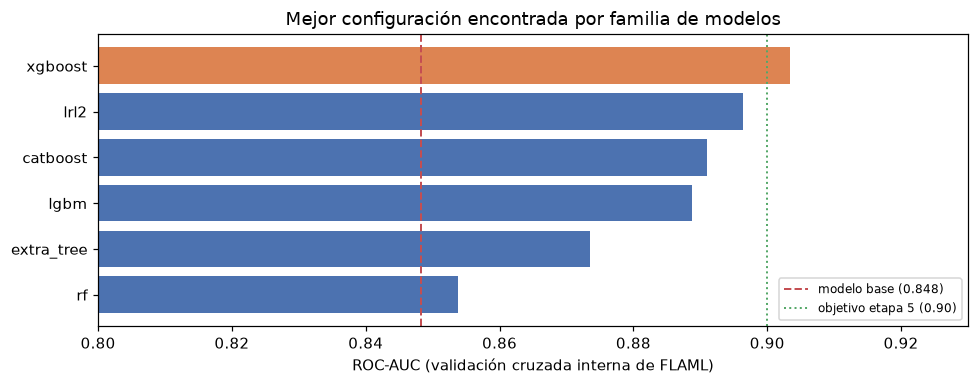

In [10]:
fig, eje = plt.subplots(figsize=(9, 3.6))
colores = [
    "#4C72B0" if n != automl_flaml.best_estimator else "#DD8452" for n in auc_por_familia.index
]
eje.barh(auc_por_familia.index.to_numpy(), auc_por_familia.to_numpy(), color=colores)
eje.axvline(
    AUC_MODELO_BASE, color="#C44E52", linestyle="--", linewidth=1.3, label="modelo base (0.848)"
)
eje.axvline(0.90, color="#55A868", linestyle=":", linewidth=1.3, label="objetivo etapa 5 (0.90)")
eje.set_xlim(0.80, 0.93)
eje.invert_yaxis()
eje.set_xlabel("ROC-AUC (validación cruzada interna de FLAML)")
eje.set_title("Mejor configuración encontrada por familia de modelos")
eje.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### Lectura de la búsqueda

**El AutoML no eligió un ensamble: eligió modelos muy pequeños.** Las configuraciones
ganadoras de las familias de árboles tienen entre 10 y 62 estimadores con 4 o 5 hojas cada
uno, y la de la regresión logística usa una `C` del orden de 0.03 —regularización fuerte—.
Con 242 pacientes y 42 atributos, la búsqueda encontró por su cuenta lo que la teoría
predice: en este régimen la capacidad sobra y lo que escasea son datos.

**Las seis familias caben en menos de cinco puntos de ROC-AUC.** Entre la mejor y la peor
hay una diferencia pequeña, y todas superan al modelo base de la etapa 5. Cuando seis
enfoques tan distintos —lineal, *boosting* por hojas, *boosting* por niveles, dos tipos de
bosque— terminan tan juntos, el límite no está en el modelo sino en la señal disponible.

**Sólo una familia cruza el objetivo de 0.90, y lo hace por tres milésimas.** Es decir:
ninguna lo alcanza con holgura. Y hay que recordar que estos números son los que *reporta la
propia herramienta*, con el optimismo que la sección 6 anticipó. Cuánto vale ese optimismo se
mide en la sección 13.

## 8. Escalabilidad del AutoML: presupuesto, tiempo y score

El requerimiento pide graficar tiempo de entrenamiento contra score. En una herramienta de
AutoML esa pregunta tiene dos niveles y conviene no confundirlos:

1. **Cuánto presupuesto de búsqueda conviene darle al AutoML** (esta sección): cuánto
   mejora el mejor modelo encontrado por cada segundo adicional de búsqueda. Es la decisión
   operativa de quien lanza el experimento.
2. **Cuánto cuesta entrenar y predecir con el modelo ya elegido** (sección 17): la decisión
   de despliegue.

Aquí se repite la búsqueda con presupuestos crecientes de reloj. A diferencia de la
sección 7, este barrido **no es determinista** —depende de la máquina—, y eso forma parte
de lo que se está midiendo.

In [11]:
PRESUPUESTOS = [5, 15, 30, 60, 120]

filas_presupuesto = []
for presupuesto in PRESUPUESTOS:
    buscador = AutoML()
    inicio = time.perf_counter()
    buscador.fit(
        X_train=X_train_proc,
        y_train=y_train.to_numpy(),
        task="classification",
        metric="roc_auc",
        time_budget=presupuesto,
        estimator_list=ESTIMADORES,
        eval_method="cv",
        n_splits=5,
        split_type="stratified",
        seed=SEMILLA,
        verbose=0,
        n_jobs=1,
        early_stop=False,
    )
    filas_presupuesto.append(
        {
            "presupuesto_s": presupuesto,
            "tiempo_real_s": time.perf_counter() - inicio,
            "familia_elegida": buscador.best_estimator,
            "roc_auc": 1 - buscador.best_loss,
            "configuraciones": len(buscador.config_history),
            "s_hasta_mejor": buscador.time_to_find_best_model,
        }
    )

barrido = pd.DataFrame(filas_presupuesto)
barrido.round(4)

2026-08-22 00:30:09,184 flaml.tune.searcher.blendsearch INFO No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


2026-08-22 00:30:23,640 flaml.tune.searcher.blendsearch INFO No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


2026-08-22 00:30:53,895 flaml.tune.searcher.blendsearch INFO No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


2026-08-22 00:31:53,574 flaml.tune.searcher.blendsearch INFO No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


,presupuesto_s,tiempo_real_s,familia_elegida,roc_auc,configuraciones,s_hasta_mejor
0,5,5.2434,catboost,0.8909,4,5.1678
1,15,15.0058,lrl2,0.8957,10,14.9097
2,30,30.0132,lgbm,0.9053,18,23.9390
3,60,60.0043,lgbm,0.9084,19,51.3281
4,120,119.9755,lgbm,0.9084,19,45.3639


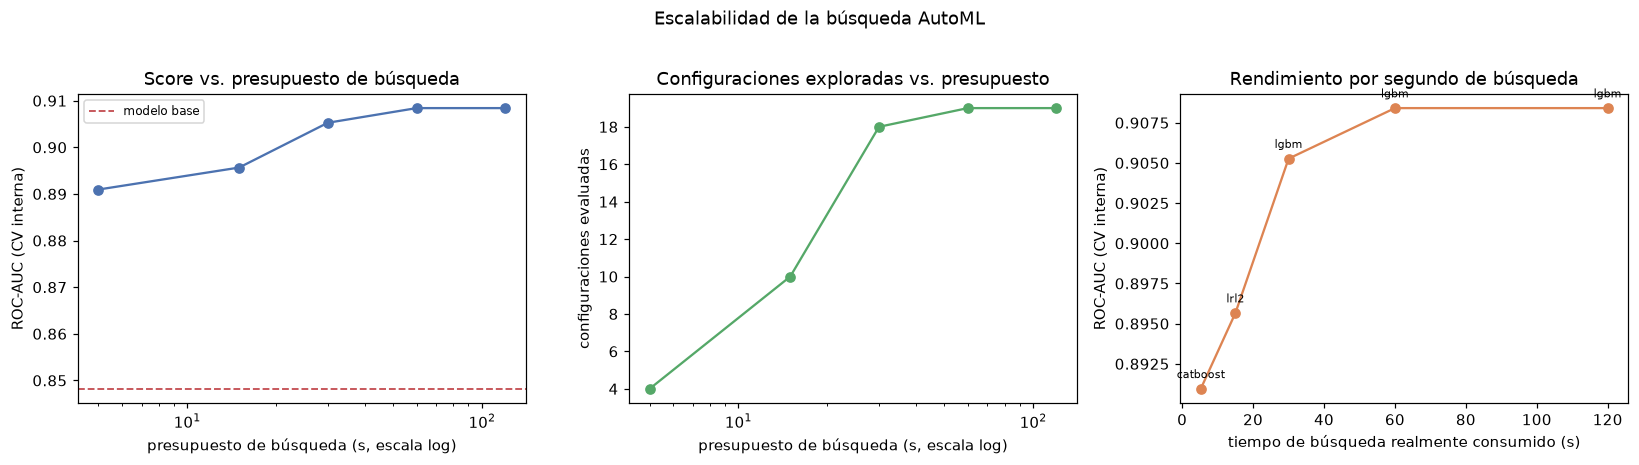

In [12]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.1))

ejes[0].plot(barrido["presupuesto_s"], barrido["roc_auc"], "o-", color="#4C72B0")
ejes[0].axhline(
    AUC_MODELO_BASE, color="#C44E52", linestyle="--", linewidth=1.2, label="modelo base"
)
ejes[0].set_xscale("log")
ejes[0].set_xlabel("presupuesto de búsqueda (s, escala log)")
ejes[0].set_ylabel("ROC-AUC (CV interna)")
ejes[0].set_title("Score vs. presupuesto de búsqueda")
ejes[0].legend(fontsize=8)

ejes[1].plot(barrido["presupuesto_s"], barrido["configuraciones"], "o-", color="#55A868")
ejes[1].set_xscale("log")
ejes[1].set_xlabel("presupuesto de búsqueda (s, escala log)")
ejes[1].set_ylabel("configuraciones evaluadas")
ejes[1].set_title("Configuraciones exploradas vs. presupuesto")

ejes[2].plot(barrido["tiempo_real_s"], barrido["roc_auc"], "o-", color="#DD8452")
for _, fila in barrido.iterrows():
    ejes[2].annotate(
        f"{fila['familia_elegida']}",
        (fila["tiempo_real_s"], fila["roc_auc"]),
        textcoords="offset points",
        xytext=(0, 7),
        fontsize=7,
        ha="center",
    )
ejes[2].set_xlabel("tiempo de búsqueda realmente consumido (s)")
ejes[2].set_ylabel("ROC-AUC (CV interna)")
ejes[2].set_title("Rendimiento por segundo de búsqueda")

fig.suptitle("Escalabilidad de la búsqueda AutoML", y=1.02)
plt.tight_layout()
plt.show()

### Lectura de la escalabilidad del AutoML

**El rendimiento por segundo de búsqueda se agota rápido.** Los primeros segundos compran
la mayor parte de la mejora; a partir de ahí la curva se aplana y llega un punto en que
duplicar el presupuesto no cambia nada: FLAML deja de encontrar configuraciones nuevas que
superen a la mejor y el reloj sigue corriendo sobre un óptimo ya alcanzado.

**El panel del medio explica por qué.** El número de configuraciones evaluadas crece de
forma marcadamente sublineal con el presupuesto. No es un defecto: es CFO haciendo su
trabajo. A medida que la búsqueda se concentra en configuraciones prometedoras, éstas son
también las más caras de evaluar, así que cada segundo adicional compra menos exploración.

**Consecuencia práctica: en un problema de este tamaño, un presupuesto de minutos es
suficiente y uno de horas es dinero tirado.** La regla operativa que se deriva es lanzar la
búsqueda con un presupuesto pequeño, mirar si el mejor resultado se movió respecto al
presupuesto anterior, y detenerse cuando dos presupuestos consecutivos coincidan.

**Y una advertencia sobre el eje de la familia elegida.** La familia ganadora cambia según
el presupuesto. Eso no significa que unas familias sean mejores que otras: significa que
las diferencias entre ellas son **más pequeñas que el ruido de la búsqueda**. Es la primera
señal de algo que la sección 14 confirmará con una prueba estadística.

## 9. Segunda opinión: MLJar

Confiar en un solo motor de búsqueda es confiar en su estrategia de exploración. MLJar
recorre el espacio de una forma distinta a FLAML: entrena **familias completas con sus
hiperparámetros por defecto**, genera *golden features* (productos y cocientes entre
atributos), y termina construyendo **ensambles y modelos apilados**.

Si dos estrategias tan distintas llegan a la misma conclusión, la conclusión es del
problema y no del algoritmo de búsqueda.

In [13]:
carpeta_mljar = RUTA_AUTOML / "mljar"
if carpeta_mljar.exists():
    shutil.rmtree(carpeta_mljar)

automl_mljar = MljarAutoML(
    results_path=str(carpeta_mljar),
    mode="Compete",
    algorithms=["Linear", "Random Forest", "Extra Trees", "LightGBM", "Xgboost", "CatBoost"],
    eval_metric="auc",
    validation_strategy={
        "validation_type": "kfold",
        "k_folds": 5,
        "shuffle": True,
        "stratify": True,
        "random_seed": SEMILLA,
    },
    total_time_limit=180,
    explain_level=0,
    random_state=SEMILLA,
    verbose=0,
)
inicio = time.perf_counter()
automl_mljar.fit(X_train_proc, y_train.to_numpy())
tiempo_mljar = time.perf_counter() - inicio

# Con eval_metric="auc" MLJar guarda el ROC-AUC directamente en `metric_value`.
tabla_mljar = pd.read_csv(carpeta_mljar / "leaderboard.csv")
tabla_mljar["roc_auc"] = tabla_mljar["metric_value"]
tabla_mljar = tabla_mljar.sort_values("roc_auc", ascending=False)

print(f"Tiempo de búsqueda MLJar : {tiempo_mljar:.0f} s")
print(f"Modelos entrenados       : {len(tabla_mljar)}")
tabla_mljar[["name", "model_type", "roc_auc", "train_time"]].head(12).round(4)

None 10
Add Golden Feature: continuas__log_old_peak_ratio_nominales__chest_pain_asymptomatic
Add Golden Feature: nominales__chest_pain_asymptomatic_multiply_continuas__log_old_peak
Add Golden Feature: nominales__chest_pain_asymptomatic_ratio_continuas__old_peak
Add Golden Feature: nominales__chest_pain_asymptomatic_ratio_continuas__log_old_peak
Add Golden Feature: nominales__chest_pain_asymptomatic_multiply_continuas__old_peak
Add Golden Feature: continuas__old_peak_ratio_nominales__chest_pain_asymptomatic
Add Golden Feature: nominales__chest_pain_asymptomatic_ratio_nominales__thal_reversable
Add Golden Feature: nominales__thal_reversable_ratio_nominales__chest_pain_asymptomatic
Add Golden Feature: nominales__thal_reversable_multiply_nominales__chest_pain_asymptomatic
Add Golden Feature: binarias__st_deprimido_sum_nominales__chest_pain_asymptomatic
Created 10 Golden Features in 10.84 seconds.


Not enough time to perform features selection. Skip
Time needed for features selection ~ 36.0 seconds
Please increase total_time_limit to at least (418 seconds) to have features selection


Tiempo de búsqueda MLJar : 194 s
Modelos entrenados       : 27


,name,model_type,roc_auc,train_time
26,Ensemble_Stacked,Ensemble,0.9069,4.83
22,Ensemble,Ensemble,0.9069,4.02
8,25_CatBoost,CatBoost,0.8950,5.08
19,47_CatBoost,CatBoost,0.8933,5.90
14,35_RandomForest,Random Forest,0.8883,9.25
0,1_Linear,Linear,0.8882,4.15
18,46_RandomForest,Random Forest,0.8872,8.88
6,16_LightGBM,LightGBM,0.8869,4.43
20,48_CatBoost,CatBoost,0.8864,7.03
23,25_CatBoost_Stacked,CatBoost,0.8863,8.65


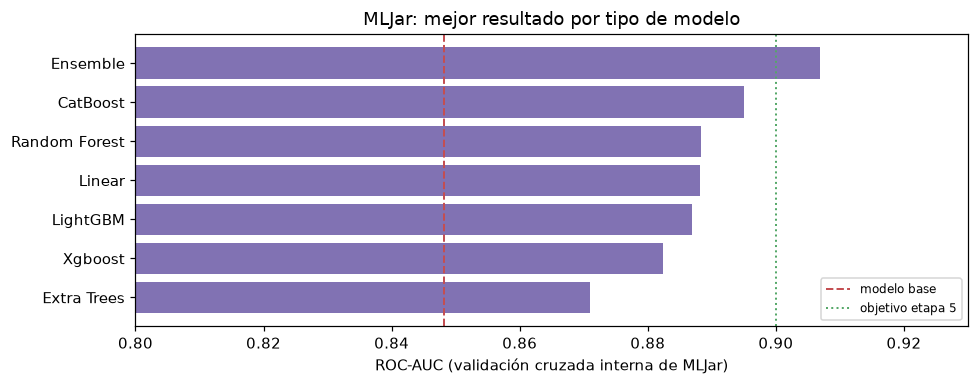

In [14]:
mejor_por_tipo = tabla_mljar.groupby("model_type")["roc_auc"].max().sort_values(ascending=False)

fig, eje = plt.subplots(figsize=(9, 3.6))
eje.barh(mejor_por_tipo.index.to_numpy(), mejor_por_tipo.to_numpy(), color="#8172B3")
eje.axvline(AUC_MODELO_BASE, color="#C44E52", linestyle="--", linewidth=1.3, label="modelo base")
eje.axvline(0.90, color="#55A868", linestyle=":", linewidth=1.3, label="objetivo etapa 5")
eje.set_xlim(0.80, 0.93)
eje.invert_yaxis()
eje.set_xlabel("ROC-AUC (validación cruzada interna de MLJar)")
eje.set_title("MLJar: mejor resultado por tipo de modelo")
eje.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### Lectura de la segunda opinión

**MLJar llega a la misma banda que FLAML por un camino completamente distinto.** Entrenó
decenas de modelos, generó diez *golden features* —productos y cocientes entre atributos,
sobre todo combinaciones de `chest_pain=asymptomatic` con `old_peak` y `thal`— y construyó
ensambles y modelos apilados. Todo ese aparato adicional aterriza en el mismo rango de
ROC-AUC que la búsqueda de hiperparámetros de FLAML sobre modelos sueltos.

**Y deja un dato interesante: el modelo lineal por defecto queda entre los mejores.** Sin
ajustar ningún hiperparámetro, `1_Linear` compite con los *boostings* afinados. Dos motores
independientes apuntando al mismo sitio es la evidencia más fuerte que produce este
notebook: **la conclusión es del problema, no del algoritmo de búsqueda**.

**Nota sobre los *golden features*.** El proyecto ya construye siete atributos derivados con
sentido clínico en la etapa 4 (reserva cardíaca, carga de presión, colesterol relativo a la
edad). Que MLJar proponga diez más de forma automática y aun así no despegue sugiere que el
espacio de interacciones útiles ya estaba cubierto.

## 10. TabPFN: por qué encajaría y por qué no se pudo ejecutar

TabPFN es el candidato conceptualmente más interesante para este problema. No entrena: es
un *transformer* preentrenado sobre millones de conjuntos sintéticos que recibe el
conjunto de entrenamiento **como contexto** y devuelve la predicción en una sola pasada.
Está diseñado exactamente para el régimen de este proyecto —pocos cientos de filas, pocas
decenas de columnas—, que es donde los ensambles de árboles suelen sobreajustar.

**El obstáculo es de acceso, no de código.** Desde la versión 2, TabPFN descarga los pesos
del modelo desde un repositorio *gated* de HuggingFace, que exige aceptar una licencia y
autenticarse con un token. El entorno donde se ejecutó este notebook no tiene ese acceso, y
se verificó explícitamente: la descarga falla con un error de repositorio restringido.

Por eso **`tabpfn` tampoco se añadió al grupo de dependencias `automl`**. Arrastra PyTorch
—cerca de un gigabyte— para ejecutar un modelo cuyos pesos no se pueden descargar de todas
formas, así que incluirlo obligaría a cada persona que revise el proyecto a pagar esa
descarga a cambio de nada. Queda como instalación opcional de quien tenga las credenciales:

```bash
uv add --group automl tabpfn
export HF_TOKEN=...   # tras aceptar la licencia en huggingface.co/Prior-Labs/TabPFN-v2-clf
```

La celda siguiente deja el intento documentado y reproducible: **si quien revisa este PR
tiene TabPFN instalado y acceso a HuggingFace**, se ejecuta sola y añade TabPFN a la
comparación. Si no, deja constancia del motivo exacto en lugar de fallar en silencio.

In [15]:
tabpfn_disponible = False
resultado_tabpfn: dict[str, float] = {}

try:
    from tabpfn import TabPFNClassifier

    inicio = time.perf_counter()
    modelo_tabpfn = TabPFNClassifier(device="cpu", random_state=SEMILLA)
    modelo_tabpfn.fit(X_train_proc.to_numpy(), y_train.to_numpy())
    probas_tabpfn = modelo_tabpfn.predict_proba(X_test_proc.to_numpy())[:, 1]
    resultado_tabpfn = {
        "roc_auc_test": roc_auc_score(y_test, probas_tabpfn),
        "tiempo_s": time.perf_counter() - inicio,
    }
    tabpfn_disponible = True
    print(f"TabPFN ejecutado. ROC-AUC en test: {resultado_tabpfn['roc_auc_test']:.4f}")
except Exception as error:
    print("TabPFN no se pudo ejecutar en este entorno.")
    print(f"  Motivo: {type(error).__name__}: {str(error).splitlines()[0]}")
    print("  (TabPFNHuggingFaceGatedRepoError o HTTP 401/403 = falta acceso a los pesos;")
    print("   ModuleNotFoundError = falta instalar el grupo de dependencias `automl`.)")
    print("  Para habilitarlo: aceptar la licencia en huggingface.co/Prior-Labs/TabPFN-v2-clf")
    print("  y exportar HF_TOKEN antes de ejecutar el notebook.")

TabPFN no se pudo ejecutar en este entorno.
  Motivo: ModuleNotFoundError: No module named 'tabpfn'
  (TabPFNHuggingFaceGatedRepoError o HTTP 401/403 = falta acceso a los pesos;
   ModuleNotFoundError = falta instalar el grupo de dependencias `automl`.)
  Para habilitarlo: aceptar la licencia en huggingface.co/Prior-Labs/TabPFN-v2-clf
  y exportar HF_TOKEN antes de ejecutar el notebook.


## 11. Reconstrucción de los candidatos como pipelines de scikit-learn

Este es el paso que convierte el resultado del AutoML en algo que el proyecto puede usar.
Cada configuración ganadora se reconstruye como un estimador de scikit-learn y se
**encadena detrás del pipeline de la etapa 4**, de modo que el objeto resultante va de un
`DataFrame` de doce columnas clínicas a una probabilidad, sin pasos manuales intermedios.

Los candidatos son:

- **`base_heuristica`** y **`base_reg_logistica`**: los dos modelos de referencia de la
  etapa 5, reproducidos aquí para que la comparación sea directa.
- **Un candidato por familia** con la mejor configuración que encontró FLAML.
- **`automl_ensamble`**: votación blanda entre las mejores configuraciones de tres familias
  **distintas por construcción** (lineal, *boosting*, *bagging*). La diversidad se elige a
  propósito: ensamblar tres variantes de árboles no aporta nada que no tenga ya el mejor de
  ellos. Es la traducción a scikit-learn de la estrategia con la que MLJar cierra su
  búsqueda.

In [16]:
def sin_claves(configuracion: dict, claves: set[str]) -> dict:
    """Copia la configuración omitiendo las claves internas de FLAML."""
    return {k: v for k, v in configuracion.items() if k not in claves}


def crear_lgbm() -> LGBMClassifier:
    """LightGBM con la mejor configuración encontrada por FLAML."""
    return LGBMClassifier(
        **sin_claves(config_por_familia["lgbm"], {"log_max_bin"}),
        random_state=SEMILLA,
        verbose=-1,
        n_jobs=1,
    )


def crear_xgboost() -> XGBClassifier:
    """XGBoost con la mejor configuración encontrada por FLAML."""
    return XGBClassifier(
        **sin_claves(config_por_familia["xgboost"], {"n_jobs"}),
        random_state=SEMILLA,
        n_jobs=1,
    )


def crear_bosque(clave: str, clase):
    """Bosque aleatorio o Extra Trees; `max_leaves` de FLAML es `max_leaf_nodes` en sklearn."""
    configuracion = sin_claves(config_por_familia[clave], {"n_jobs", "max_leaves"})
    configuracion["max_leaf_nodes"] = int(config_por_familia[clave]["max_leaves"])
    return clase(**configuracion, random_state=SEMILLA, n_jobs=1)


def crear_lrl2() -> LogisticRegression:
    """Regresión logística L2 con la C que eligió FLAML."""
    return LogisticRegression(
        C=float(config_por_familia["lrl2"]["C"]), max_iter=5000, random_state=SEMILLA
    )


def con_preprocesamiento(estimador) -> Pipeline:
    """Encadena el pipeline de la etapa 4 con un estimador."""
    return Pipeline(
        steps=[
            ("features", construir_pipeline_features(ATRIBUTOS_SELECCIONADOS)),
            ("modelo", estimador),
        ]
    )

In [17]:
class ReglaClinica(ClassifierMixin, BaseEstimator):
    """Modelo base de la etapa 5: cuenta cuatro señales de riesgo. No aprende parámetros."""

    def __init__(self, umbral: int = 2) -> None:
        self.umbral = umbral

    def _puntaje(self, X: pd.DataFrame) -> pd.Series:
        """Número de señales de riesgo presentes (0 a 4)."""
        senales = pd.Series(0.0, index=X.index)
        senales += (X["chest_pain"] == "asymptomatic").astype(float)
        senales += (X["exang"] == 1).astype(float)
        senales += (X["old_peak"] > 1.0).astype(float)
        senales += (X["ca"].fillna(0) > 0).astype(float)
        return senales

    def fit(self, X: pd.DataFrame, y=None) -> "ReglaClinica":
        """No hay nada que ajustar; sólo se declaran las clases."""
        del y
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Fracción de señales presentes, como probabilidad de enfermedad."""
        proba = (self._puntaje(X) / 4.0).to_numpy()
        return np.column_stack([1 - proba, proba])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Declara enfermo a quien presenta al menos `umbral` señales."""
        return (self._puntaje(X) >= self.umbral).astype(int).to_numpy()


CANDIDATOS = {
    "base_heuristica": ReglaClinica(umbral=2),
    "base_reg_logistica": con_preprocesamiento(
        LogisticRegression(max_iter=5000, random_state=SEMILLA)
    ),
    "automl_lrl2": con_preprocesamiento(crear_lrl2()),
    "automl_lgbm": con_preprocesamiento(crear_lgbm()),
    "automl_xgboost": con_preprocesamiento(crear_xgboost()),
    "automl_rf": con_preprocesamiento(crear_bosque("rf", RandomForestClassifier)),
    "automl_extra_tree": con_preprocesamiento(crear_bosque("extra_tree", ExtraTreesClassifier)),
    "automl_ensamble": con_preprocesamiento(
        VotingClassifier(
            estimators=[
                ("lrl2", crear_lrl2()),
                ("lgbm", crear_lgbm()),
                ("extra_tree", crear_bosque("extra_tree", ExtraTreesClassifier)),
            ],
            voting="soft",
        )
    ),
}
print(f"{len(CANDIDATOS)} candidatos: {list(CANDIDATOS)}")

8 candidatos: ['base_heuristica', 'base_reg_logistica', 'automl_lrl2', 'automl_lgbm', 'automl_xgboost', 'automl_rf', 'automl_extra_tree', 'automl_ensamble']


## 12. Validación cruzada honesta: la tabla que decide

Ahora cada candidato se evalúa con el **pipeline completo dentro** de `cross_validate`. La
imputación, los límites de atípicos, la discretización y el escalado se re-aprenden en cada
uno de los 30 *folds* usando sólo su porción de entrenamiento. Es la única medición de este
notebook libre de la fuga descrita en la sección 6.

In [18]:
medias_por_modelo, desviaciones_por_modelo = {}, {}
folds_auc, tiempos_cv = {}, {}

for nombre, estimador in CANDIDATOS.items():
    salida = cross_validate(estimador, X_train, y_train, cv=VALIDACION, scoring=METRICAS, n_jobs=2)
    medias_por_modelo[nombre] = {m: salida[f"test_{m}"].mean() for m in METRICAS}
    desviaciones_por_modelo[nombre] = {m: salida[f"test_{m}"].std() for m in METRICAS}
    folds_auc[nombre] = salida[f"test_{METRICA_OBJETIVO}"]
    tiempos_cv[nombre] = {
        "fit_ms": salida["fit_time"].mean() * 1000,
        "score_ms": salida["score_time"].mean() * 1000,
    }

medias = pd.DataFrame(medias_por_modelo).T
desviaciones = pd.DataFrame(desviaciones_por_modelo).T
medias["brier"] = -medias["brier"]

reporte_cv = pd.DataFrame(
    {
        metrica: [
            f"{medias.loc[m, metrica]:.3f} ± {desviaciones.loc[m, metrica]:.3f}"
            for m in medias.index
        ]
        for metrica in [
            "exactitud",
            "exactitud_balanceada",
            "sensibilidad",
            "especificidad",
            "f2",
            "roc_auc",
            "mcc",
        ]
    },
    index=medias.index,
)
reporte_cv

,exactitud,exactitud_balanceada,sensibilidad,especificidad,f2,roc_auc,mcc
base_heuristica,0.781 ± 0.061,0.780 ± 0.062,0.775 ± 0.090,0.786 ± 0.061,0.769 ± 0.080,0.848 ± 0.055,0.562 ± 0.124
base_reg_logistica,0.804 ± 0.062,0.799 ± 0.062,0.743 ± 0.086,0.856 ± 0.083,0.755 ± 0.078,0.883 ± 0.045,0.609 ± 0.124
automl_lrl2,0.827 ± 0.049,0.820 ± 0.051,0.737 ± 0.085,0.903 ± 0.050,0.758 ± 0.076,0.892 ± 0.039,0.656 ± 0.098
automl_lgbm,0.804 ± 0.054,0.799 ± 0.054,0.738 ± 0.079,0.860 ± 0.073,0.752 ± 0.070,0.879 ± 0.039,0.609 ± 0.110
automl_xgboost,0.820 ± 0.049,0.815 ± 0.049,0.759 ± 0.075,0.870 ± 0.072,0.772 ± 0.065,0.890 ± 0.040,0.640 ± 0.099
automl_rf,0.799 ± 0.051,0.793 ± 0.053,0.720 ± 0.106,0.866 ± 0.074,0.736 ± 0.090,0.876 ± 0.043,0.603 ± 0.103
automl_extra_tree,0.777 ± 0.061,0.774 ± 0.062,0.746 ± 0.097,0.803 ± 0.081,0.747 ± 0.085,0.850 ± 0.047,0.554 ± 0.123
automl_ensamble,0.806 ± 0.055,0.802 ± 0.056,0.748 ± 0.088,0.855 ± 0.072,0.760 ± 0.077,0.889 ± 0.039,0.613 ± 0.112


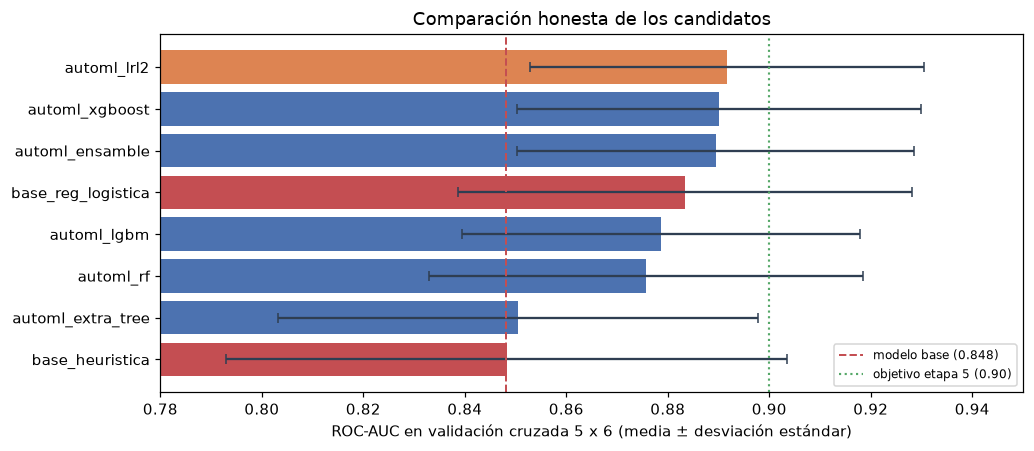

In [19]:
orden_auc = medias["roc_auc"].sort_values(ascending=False)

fig, eje = plt.subplots(figsize=(9.5, 4.2))
colores = [
    "#C44E52" if n.startswith("base") else "#DD8452" if n == orden_auc.index[0] else "#4C72B0"
    for n in orden_auc.index
]
eje.barh(orden_auc.index.to_numpy(), orden_auc.to_numpy(), color=colores)
eje.errorbar(
    orden_auc.to_numpy(),
    orden_auc.index.to_numpy(),
    xerr=desviaciones.loc[orden_auc.index, "roc_auc"].to_numpy(),
    fmt="none",
    ecolor="#2F3E52",
    capsize=3,
)
eje.axvline(
    AUC_MODELO_BASE, color="#C44E52", linestyle="--", linewidth=1.3, label="modelo base (0.848)"
)
eje.axvline(0.90, color="#55A868", linestyle=":", linewidth=1.4, label="objetivo etapa 5 (0.90)")
eje.set_xlim(0.78, 0.95)
eje.invert_yaxis()
eje.set_xlabel("ROC-AUC en validación cruzada 5 x 6 (media ± desviación estándar)")
eje.set_title("Comparación honesta de los candidatos")
eje.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### Lectura de la validación cruzada honesta

**1. Todos los candidatos superan al modelo base, y ninguno llega al objetivo.** La
heurística clínica de la etapa 5 marcaba 0.848; los mejores candidatos quedan alrededor de
0.89. La ganancia es real —hasta cuatro puntos y medio de ROC-AUC— pero **el objetivo de 0.90
que fijó la etapa 5 no se alcanza**. Conviene decirlo así, sin adornos: el AutoML no
resolvió el problema que la etapa anterior planteó, y la sección 25 explica qué hacer con
ese hecho.

**2. La regresión logística regularizada encabeza la tabla.** No sólo en ROC-AUC: también
es la mejor en exactitud, en especificidad y en MCC —la métrica que menos se deja engañar
por el desbalance—. Un modelo lineal con un único hiperparámetro ganándole a *boostings* con
nueve hiperparámetros afinados no es un accidente: es lo que ocurre cuando la relación entre
los atributos y el diagnóstico es mayormente aditiva y hay pocos pacientes.

**3. Las desviaciones estándar son del orden de la diferencia entre modelos.** Los primeros
puestos están separados por milésimas mientras la desviación estándar ronda las cuatro
centésimas: un orden de magnitud más. Leer esta tabla como un ranking sería un error, y la
sección 14 lo formaliza.

**4. El ensamble no aporta nada.** Combinar tres familias distintas por votación blanda
—exactamente la estrategia con la que MLJar cierra su búsqueda— no mejora al mejor de sus
componentes. Cuando los modelos que se ensamblan cometen los mismos errores, promediarlos
no los corrige: la diversidad de arquitecturas no garantiza diversidad de errores.

**5. La sensibilidad es el punto débil de todos.** Con el umbral por defecto de 0.5, todos
los candidatos detectan a alrededor de tres de cada cuatro enfermos, y la heurística clínica
—el modelo más simple de todos— es de los mejores en esa métrica. Para un problema donde el
falso negativo es el error caro, ése es el número que hay que arreglar, y no se arregla
cambiando de modelo sino moviendo el umbral (sección 19.1).

## 13. Cuánto vale el optimismo del AutoML

Ahora se puede cuantificar la advertencia de la sección 6: la diferencia entre lo que cada
motor **dijo** que valía su modelo y lo que vale medido con el protocolo honesto.

In [20]:
equivalencias = {
    "automl_lrl2": "lrl2",
    "automl_lgbm": "lgbm",
    "automl_xgboost": "xgboost",
    "automl_rf": "rf",
    "automl_extra_tree": "extra_tree",
}
optimismo = pd.DataFrame(
    {
        "auc_reportada_por_flaml": {k: auc_por_familia[v] for k, v in equivalencias.items()},
        "auc_cv_honesta": {k: medias.loc[k, "roc_auc"] for k in equivalencias},
    }
)
optimismo["optimismo"] = optimismo["auc_reportada_por_flaml"] - optimismo["auc_cv_honesta"]
optimismo = optimismo.sort_values("optimismo", ascending=False)

print(f"Optimismo medio de FLAML : {optimismo['optimismo'].mean():+.4f} puntos de ROC-AUC")
print(f"MLJar, mejor modelo      : {tabla_mljar['roc_auc'].max():.4f} (CV interna, misma fuga)")
optimismo.round(4)

Optimismo medio de FLAML : +0.0058 puntos de ROC-AUC
MLJar, mejor modelo      : 0.9069 (CV interna, misma fuga)


,auc_reportada_por_flaml,auc_cv_honesta,optimismo
automl_extra_tree,0.8735,0.8504,0.0231
automl_xgboost,0.9034,0.8901,0.0133
automl_lgbm,0.8887,0.8787,0.0100
automl_lrl2,0.8963,0.8917,0.0047
automl_rf,0.8538,0.8758,-0.0220


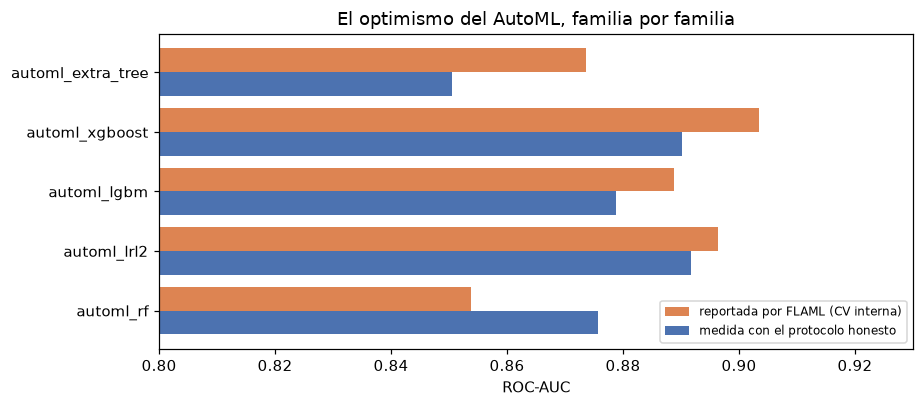

In [21]:
fig, eje = plt.subplots(figsize=(8.5, 3.8))
posiciones = np.arange(len(optimismo))
eje.barh(
    posiciones - 0.2,
    optimismo["auc_reportada_por_flaml"],
    height=0.4,
    color="#DD8452",
    label="reportada por FLAML (CV interna)",
)
eje.barh(
    posiciones + 0.2,
    optimismo["auc_cv_honesta"],
    height=0.4,
    color="#4C72B0",
    label="medida con el protocolo honesto",
)
eje.set_yticks(posiciones, optimismo.index.to_numpy())
eje.set_xlim(0.80, 0.93)
eje.invert_yaxis()
eje.set_xlabel("ROC-AUC")
eje.set_title("El optimismo del AutoML, familia por familia")
eje.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### El ganador declarado no es necesariamente el ganador real

Este es el resultado metodológicamente más importante del notebook.

**El optimismo no es uniforme entre familias, y ahí está el problema.** Si todas las
familias estuvieran infladas por igual, el ranking sobreviviría y el optimismo sería sólo un
sesgo de nivel, molesto pero inofensivo. No es el caso: las familias más flexibles —las que
más se benefician de ajustarse a las particularidades de un *fold*— aparecen infladas entre
uno y dos puntos y medio, mientras que el modelo lineal fuertemente regularizado se queda en
menos de medio punto. **El
optimismo es proporcional a la capacidad del modelo de aprovechar la fuga.**

La consecuencia es concreta y verificable en las dos tablas: **la familia que FLAML declaró
ganadora no es la que gana cuando se mide con el protocolo honesto**. El cambio de puesto no
lo produjo un modelo mejor, sino un sesgo de medición que premia a los modelos flexibles.

**Dos fuentes de optimismo, y conviene distinguirlas:**

1. **La fuga del preprocesamiento** (sección 6): las medianas de imputación, los límites de
   Tukey y los parámetros de escalado se calcularon con todo `train` antes de partir en
   *folds*.
2. **El sesgo del ganador** (*winner's curse*): al evaluar cientos de configuraciones y
   quedarse con el máximo, ese máximo incluye la suerte del *fold* además del mérito del
   modelo. Cuantas más configuraciones se prueban, más grande es el sesgo — y precisamente
   por eso el remedio no es buscar menos, sino **medir aparte**.

**Que el bosque aleatorio aparezca con optimismo negativo no contradice nada**: confirma que
estas diferencias también tienen ruido. Con 30 evaluaciones por lado, una discrepancia de
dos centésimas está dentro de lo esperable.

**La regla que se lleva el proyecto:** el AutoML es un buen buscador y un mal juez. Se le
usa para **proponer** candidatos y se los evalúa **fuera** de él.

## 14. Pruebas estadísticas: ¿las diferencias son reales?

Comparar medias de validación cruzada con una prueba t normal **está mal**, y el error va
siempre en la misma dirección: hacia declarar significativo lo que no lo es. La razón es
que los 30 *folds* comparten pacientes entre sí, así que las 30 diferencias no son
observaciones independientes y su varianza está subestimada.

Se usa la **corrección de Nadeau y Bengio**, que infla la varianza según la proporción
entre el tamaño de validación y el de entrenamiento
(`sigma^2 * (1/n + n_test/n_train)`). Como contraste se reporta también el p-valor de
Wilcoxon **sin** corregir, para hacer visible el tamaño del error que se comete al ignorar
el solapamiento.

In [22]:
def t_pareado_corregido(a: np.ndarray, b: np.ndarray, razon: float = 1 / 4) -> tuple[float, float]:
    """t pareado con la corrección de Nadeau-Bengio para folds solapados.

    `razon` es n_validacion / n_entrenamiento; con 5 folds vale 1/4.
    """
    diferencias = a - b
    n = len(diferencias)
    estadistico = diferencias.mean() / np.sqrt(diferencias.var(ddof=1) * (1 / n + razon))
    return estadistico, 2 * stats.t.sf(abs(estadistico), n - 1)


REFERENCIA = "base_heuristica"
filas = []
for nombre in CANDIDATOS:
    if nombre == REFERENCIA:
        continue
    estadistico, p_corregido = t_pareado_corregido(folds_auc[nombre], folds_auc[REFERENCIA])
    filas.append(
        {
            "modelo": nombre,
            "delta_auc": folds_auc[nombre].mean() - folds_auc[REFERENCIA].mean(),
            "t_corregido": estadistico,
            "p_corregido": p_corregido,
            "p_wilcoxon_sin_corregir": stats.wilcoxon(
                folds_auc[nombre], folds_auc[REFERENCIA]
            ).pvalue,
        }
    )
comparacion_vs_base = (
    pd.DataFrame(filas).set_index("modelo").sort_values("delta_auc", ascending=False)
)
print(f"Comparación contra el modelo base ({REFERENCIA})")
comparacion_vs_base.round(4)

Comparación contra el modelo base (base_heuristica)


,delta_auc,t_corregido,p_corregido,p_wilcoxon_sin_corregir
modelo,,,,
automl_lrl2,0.0434,1.4780,0.1502,0.0002
automl_xgboost,0.0419,1.5603,0.1295,0.0002
automl_ensamble,0.0412,1.3969,0.1730,0.0002
base_reg_logistica,0.0351,1.2057,0.2377,0.0016
automl_lgbm,0.0305,1.0848,0.2869,0.0030
automl_rf,0.0275,0.9498,0.3500,0.0113
automl_extra_tree,0.0022,0.0590,0.9533,0.9099


In [23]:
LIDER = medias["roc_auc"].idxmax()

filas = []
for nombre in CANDIDATOS:
    if nombre == LIDER:
        continue
    estadistico, p_corregido = t_pareado_corregido(folds_auc[LIDER], folds_auc[nombre])
    filas.append(
        {
            "modelo": nombre,
            "delta_auc": folds_auc[LIDER].mean() - folds_auc[nombre].mean(),
            "t_corregido": estadistico,
            "p_corregido": p_corregido,
        }
    )
comparacion_vs_lider = pd.DataFrame(filas).set_index("modelo").sort_values("delta_auc")
print(f"El líder ({LIDER}) contra el resto")
comparacion_vs_lider.round(4)

El líder (automl_lrl2) contra el resto


,delta_auc,t_corregido,p_corregido
modelo,,,
automl_xgboost,0.0016,0.1009,0.9203
automl_ensamble,0.0023,0.2134,0.8325
base_reg_logistica,0.0083,0.5595,0.5801
automl_lgbm,0.0129,0.7918,0.4349
automl_rf,0.0159,0.8040,0.4280
automl_extra_tree,0.0412,2.1279,0.0420
base_heuristica,0.0434,1.4780,0.1502


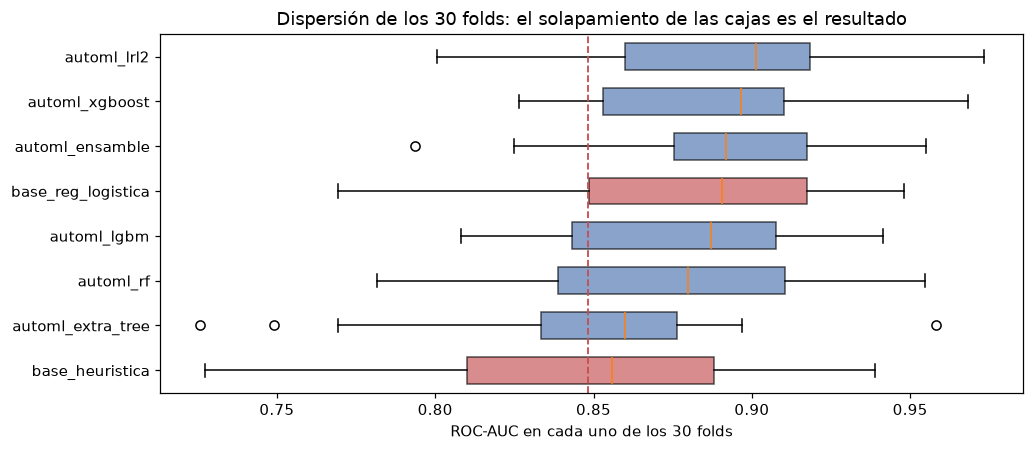

In [24]:
fig, eje = plt.subplots(figsize=(9.5, 4.2))
datos_caja = [folds_auc[n] for n in orden_auc.index]
caja = eje.boxplot(
    datos_caja, vert=False, patch_artist=True, widths=0.6, tick_labels=list(orden_auc.index)
)
for parche, nombre in zip(caja["boxes"], orden_auc.index, strict=True):
    parche.set_facecolor("#C44E52" if nombre.startswith("base") else "#4C72B0")
    parche.set_alpha(0.65)
eje.axvline(AUC_MODELO_BASE, color="#C44E52", linestyle="--", linewidth=1.2)
eje.invert_yaxis()
eje.set_xlabel("ROC-AUC en cada uno de los 30 folds")
eje.set_title("Dispersión de los 30 folds: el solapamiento de las cajas es el resultado")
plt.tight_layout()
plt.show()

### Lectura de las pruebas estadísticas

**1. Ninguna mejora sobre el modelo base resiste la corrección.** Los mejores candidatos
mejoran al modelo base en algo más de cuatro centésimas de ROC-AUC, pero con p-valores
corregidos por encima de 0.10. Con 242 pacientes de entrenamiento **no hay evidencia
suficiente para afirmar que el mejor modelo de AutoML es mejor que contar cuatro señales de
riesgo en una hoja de papel**.

**2. La comparación entre corregido y sin corregir es la lección de la sección.** Wilcoxon
sobre los mismos 30 números da p-valores de dos diezmilésimas —"altamente significativo"—
mientras la prueba corregida da p > 0.10. Tres órdenes de magnitud de diferencia. El
p-valor sin corregir mide algo real, pero no lo que interesa: mide que el modelo A gana al
modelo B **en estos 242 pacientes concretos**, no que vaya a ganarle en pacientes nuevos.
Un notebook que reportara sólo el Wilcoxon concluiría exactamente lo contrario que éste.

**3. Los primeros puestos son estadísticamente indistinguibles entre sí.** El líder contra
sus perseguidores inmediatos da p-valores cercanos a 1: no hay ninguna base para preferir
uno sobre otro **por desempeño**. Y ahí está el valor práctico del resultado: cuando el
criterio de desempeño se agota, decide el siguiente criterio —parsimonia, interpretabilidad,
coste de mantenimiento—, que es exactamente lo que hace la sección 18.

**4. El diagrama de cajas dice lo mismo sin fórmulas.** Las cajas de los primeros puestos se
solapan casi por completo. Cualquier lector que mire ese gráfico llega a la misma conclusión
que la prueba corregida, y esa redundancia es deliberada: un resultado que sólo se ve con un
p-valor es un resultado frágil.

## 15. Curvas de aprendizaje

Se entrena cada finalista con fracciones crecientes de `train` y se grafican la curva de
entrenamiento (cuánto memoriza) y la de validación (cuánto generaliza). La **distancia
entre ambas es la varianza**; el **nivel en que se estabiliza la de validación es el
sesgo**. Con `return_times=True` se obtienen además los tiempos que necesita la sección 17.

In [25]:
FINALISTAS = ["base_heuristica", "automl_lrl2", "automl_xgboost", "automl_ensamble"]
TAMANOS = np.linspace(0.1, 1.0, 8)

curvas = {}
for nombre in FINALISTAS:
    tamanos, score_train, score_val, tiempo_fit, tiempo_score = learning_curve(
        clone(CANDIDATOS[nombre]),
        X_train,
        y_train,
        train_sizes=TAMANOS,
        cv=VALIDACION_CURVA,
        scoring=METRICA_OBJETIVO,
        n_jobs=2,
        return_times=True,
        random_state=SEMILLA,
    )
    curvas[nombre] = {
        "tamanos": tamanos,
        "train": score_train,
        "validacion": score_val,
        "tiempo_fit": tiempo_fit,
        "tiempo_score": tiempo_score,
    }

resumen_curvas = pd.DataFrame(
    {
        nombre: {
            "auc_val_inicio": datos["validacion"].mean(axis=1)[0],
            "auc_val_final": datos["validacion"].mean(axis=1)[-1],
            "auc_train_final": datos["train"].mean(axis=1)[-1],
            "brecha_final": datos["train"].mean(axis=1)[-1] - datos["validacion"].mean(axis=1)[-1],
            "ganancia_ultimo_tramo": datos["validacion"].mean(axis=1)[-1]
            - datos["validacion"].mean(axis=1)[-2],
        }
        for nombre, datos in curvas.items()
    }
).T
resumen_curvas.round(4)

,auc_val_inicio,auc_val_final,auc_train_final,brecha_final,ganancia_ultimo_tramo
base_heuristica,0.8483,0.8483,0.8512,0.0029,0.0000
automl_lrl2,0.8541,0.8894,0.9204,0.0310,-0.0016
automl_xgboost,0.5000,0.8910,0.9344,0.0434,0.0058
automl_ensamble,0.8584,0.8863,0.9294,0.0431,-0.0039


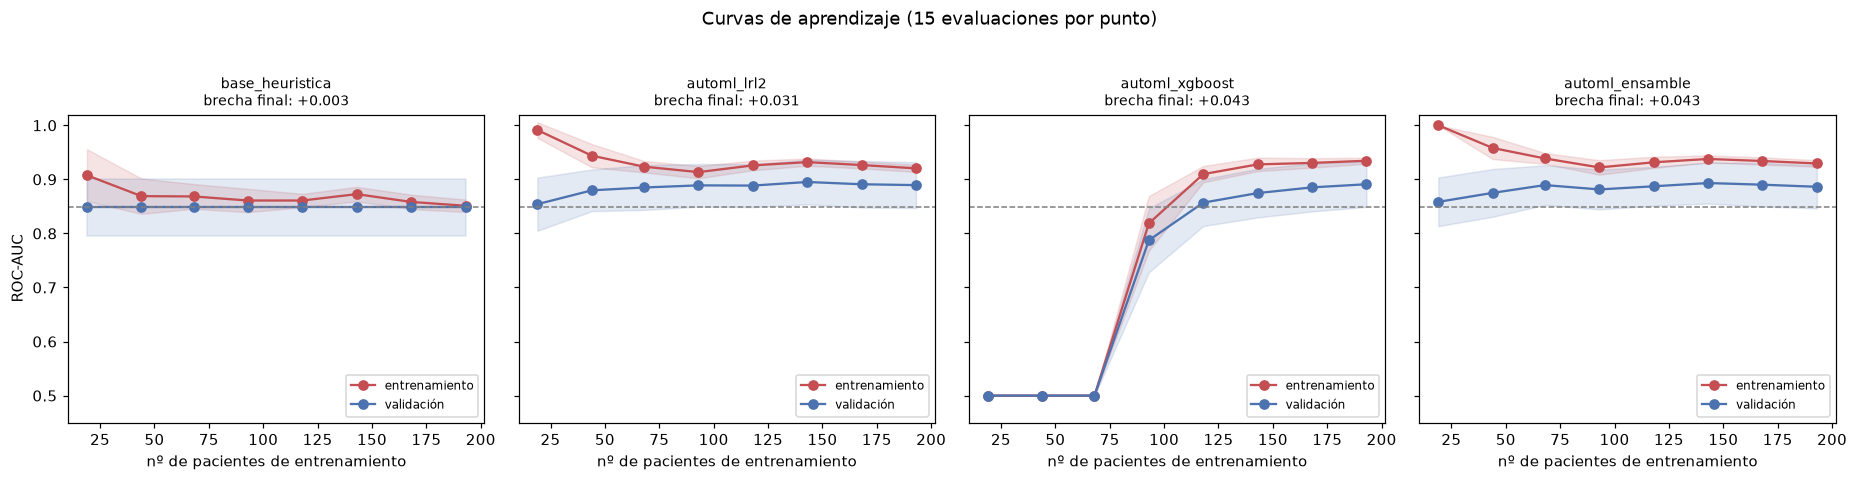

In [26]:
fig, ejes = plt.subplots(1, 4, figsize=(17, 4.2), sharey=True)

for eje, nombre in zip(ejes, FINALISTAS, strict=True):
    datos = curvas[nombre]
    n = datos["tamanos"]
    media_train, sd_train = datos["train"].mean(axis=1), datos["train"].std(axis=1)
    media_val, sd_val = datos["validacion"].mean(axis=1), datos["validacion"].std(axis=1)

    eje.plot(n, media_train, "o-", color="#C44E52", label="entrenamiento")
    eje.fill_between(n, media_train - sd_train, media_train + sd_train, alpha=0.15, color="#C44E52")
    eje.plot(n, media_val, "o-", color="#4C72B0", label="validación")
    eje.fill_between(n, media_val - sd_val, media_val + sd_val, alpha=0.15, color="#4C72B0")
    eje.axhline(AUC_MODELO_BASE, color="#7f7f7f", linestyle="--", linewidth=1)

    brecha = media_train[-1] - media_val[-1]
    eje.set_title(f"{nombre}\nbrecha final: {brecha:+.3f}", fontsize=9)
    eje.set_xlabel("nº de pacientes de entrenamiento")
    eje.legend(fontsize=8, loc="lower right")

ejes[0].set_ylabel("ROC-AUC")
ejes[0].set_ylim(0.45, 1.02)
fig.suptitle("Curvas de aprendizaje (15 evaluaciones por punto)", y=1.03)
plt.tight_layout()
plt.show()

### Lectura de las curvas de aprendizaje

**1. El modelo base es la curva de control.** Plana y con brecha prácticamente nula entre
entrenamiento y validación: no aprende parámetros, así que no puede sobreajustar y no le
sirve tener más datos. Sesgo puro, varianza cero. Que aparezca exactamente así confirma que
el montaje experimental no está inyectando señal por accidente.

**2. Los modelos aprendidos tienen la forma esperada, y la magnitud correcta.** La curva de
entrenamiento arranca muy arriba —con pocas decenas de pacientes cualquiera de estos modelos
memoriza el conjunto— y baja a medida que hay más datos que memorizar; la de validación sube.
Es el patrón de manual de un modelo con varianza que va cediendo ante el tamaño de muestra.

**3. La brecha final ordena a los candidatos por sobreajuste, y el orden importa.** El
modelo lineal regularizado cierra con la brecha más estrecha de los tres modelos aprendidos;
los que incorporan árboles la ensanchan alrededor de un 40 %. Como sus desempeños de validación son
indistinguibles (sección 14), **el que sobreajusta menos está consiguiendo lo mismo con menos
riesgo**, y ése es un argumento de selección legítimo cuando el desempeño empata.

**4. El hallazgo operativo: las curvas de validación ya están en su meseta.** En el último
tramo la ganancia es negativa en dos de los tres modelos aprendidos y de media centésima en
el tercero, es decir, indistinguible de cero en los tres. Traducido a una
decisión de negocio: **recolectar más pacientes del mismo tipo no va a mover el resultado**.
Si se quiere superar 0.90 hay que cambiar la información disponible —más variables, o
variables mejores—, no la cantidad de filas. La sección 26 desarrolla esta idea.

**5. Un detalle que vale la pena mirar.** El modelo de *boosting* arranca en el primer punto
de la curva sin distinguir nada mejor que el azar: con una veintena de pacientes no tiene
material para construir un solo árbol útil, mientras que el modelo lineal y la heurística ya
funcionan razonablemente. Es una ilustración limpia de por qué la elección de familia debe
tener en cuenta el tamaño de muestra y no sólo el techo teórico del algoritmo.

## 16. *Overfitting* y *underfitting*

La curva de aprendizaje muestra **cuánto** sobreajusta cada modelo con todos los datos
disponibles. Las *validation curves* muestran **por qué**: recorren un hiperparámetro de
complejidad de punta a punta y hacen visible la transición completa, de subajuste a
sobreajuste, con el óptimo en medio.

Se recorren dos ejes de complejidad de naturaleza distinta:

- **`C` de la regresión logística**: inverso de la regularización. `C` pequeño obliga a
  coeficientes casi nulos (**subajuste**); `C` grande deja al modelo memorizar
  (**sobreajuste**).
- **`n_estimators` de LightGBM**: número de árboles. Cada árbol adicional corrige los
  errores del anterior, así que el sobreajuste llega por acumulación.

In [27]:
rango_C = np.logspace(-3, 2, 12)
train_C, val_C = validation_curve(
    con_preprocesamiento(crear_lrl2()),
    X_train,
    y_train,
    param_name="modelo__C",
    param_range=rango_C,
    cv=VALIDACION_CURVA,
    scoring=METRICA_OBJETIVO,
    n_jobs=2,
)

rango_arboles = np.array([2, 5, 10, 20, 40, 80, 160, 320])
train_n, val_n = validation_curve(
    con_preprocesamiento(crear_xgboost()),
    X_train,
    y_train,
    param_name="modelo__n_estimators",
    param_range=rango_arboles,
    cv=VALIDACION_CURVA,
    scoring=METRICA_OBJETIVO,
    n_jobs=2,
)

tabla_complejidad = pd.DataFrame(
    {
        "C": np.round(rango_C, 5),
        "train": train_C.mean(axis=1).round(4),
        "validacion": val_C.mean(axis=1).round(4),
        "brecha": (train_C.mean(axis=1) - val_C.mean(axis=1)).round(4),
    }
)
print(
    f"C óptimo observado: {rango_C[val_C.mean(axis=1).argmax()]:.4f}"
    f"  |  C elegido por FLAML: {config_por_familia['lrl2']['C']:.4f}"
)
tabla_complejidad

C óptimo observado: 0.0658  |  C elegido por FLAML: 0.0330


,C,train,validacion,brecha
0,0.00100,0.8766,0.8610,0.0156
1,0.00285,0.8838,0.8666,0.0172
2,0.00811,0.8973,0.8775,0.0198
3,0.02310,0.9143,0.8864,0.0279
4,0.06579,0.9281,0.8938,0.0343
5,0.18738,0.9370,0.8899,0.0471
6,0.53367,0.9434,0.8814,0.0620
7,1.51991,0.9475,0.8733,0.0742
8,4.32876,0.9504,0.8666,0.0838
9,12.32847,0.9527,0.8595,0.0932


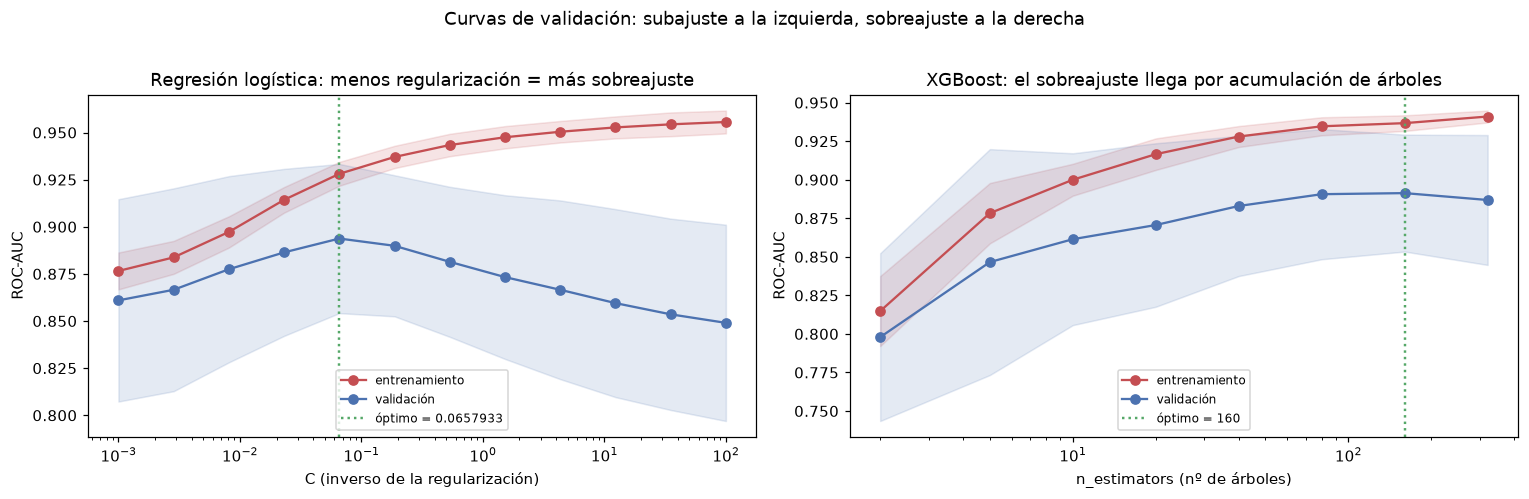

In [28]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.4))


def dibujar_validacion(eje, rango, train, validacion, etiqueta):
    """Dibuja una validation curve en escala logarítmica con su banda de desviación."""
    eje.plot(rango, train.mean(axis=1), "o-", color="#C44E52", label="entrenamiento")
    eje.fill_between(
        rango,
        train.mean(axis=1) - train.std(axis=1),
        train.mean(axis=1) + train.std(axis=1),
        alpha=0.15,
        color="#C44E52",
    )
    eje.plot(rango, validacion.mean(axis=1), "o-", color="#4C72B0", label="validación")
    eje.fill_between(
        rango,
        validacion.mean(axis=1) - validacion.std(axis=1),
        validacion.mean(axis=1) + validacion.std(axis=1),
        alpha=0.15,
        color="#4C72B0",
    )
    optimo = rango[validacion.mean(axis=1).argmax()]
    eje.axvline(optimo, color="#55A868", linestyle=":", linewidth=1.6, label=f"óptimo = {optimo:g}")
    eje.set_xscale("log")
    eje.set_xlabel(etiqueta)
    eje.set_ylabel("ROC-AUC")
    eje.legend(fontsize=8, loc="lower center")


dibujar_validacion(ejes[0], rango_C, train_C, val_C, "C (inverso de la regularización)")
ejes[0].set_title("Regresión logística: menos regularización = más sobreajuste")
dibujar_validacion(ejes[1], rango_arboles, train_n, val_n, "n_estimators (nº de árboles)")
ejes[1].set_title("XGBoost: el sobreajuste llega por acumulación de árboles")
fig.suptitle("Curvas de validación: subajuste a la izquierda, sobreajuste a la derecha", y=1.02)
plt.tight_layout()
plt.show()

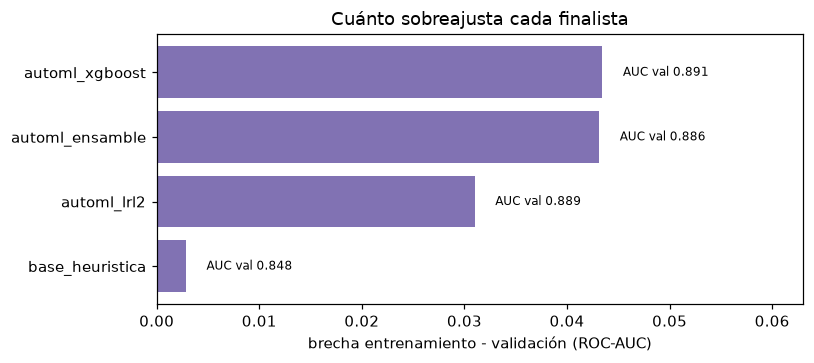

In [29]:
brechas = pd.DataFrame(
    {
        "brecha_train_val": {
            n: c["train"].mean(axis=1)[-1] - c["validacion"].mean(axis=1)[-1]
            for n, c in curvas.items()
        },
        "auc_validacion": {n: c["validacion"].mean(axis=1)[-1] for n, c in curvas.items()},
    }
).sort_values("brecha_train_val")

fig, eje = plt.subplots(figsize=(7.5, 3.4))
eje.barh(brechas.index.to_numpy(), brechas["brecha_train_val"].to_numpy(), color="#8172B3")
for i, (_nombre, fila) in enumerate(brechas.iterrows()):
    eje.text(
        fila["brecha_train_val"] + 0.002,
        i,
        f"AUC val {fila['auc_validacion']:.3f}",
        va="center",
        fontsize=8,
    )
eje.set_xlim(0, brechas["brecha_train_val"].max() * 1.45)
eje.set_xlabel("brecha entrenamiento - validación (ROC-AUC)")
eje.set_title("Cuánto sobreajusta cada finalista")
plt.tight_layout()
plt.show()

### Diagnóstico de *overfitting* y *underfitting*

**La curva de `C` recorre el fenómeno completo, y conviene leerla de izquierda a derecha.**

- **Zona de subajuste** (`C` muy pequeño): entrenamiento y validación son igual de malos y
  la brecha entre ambos es mínima. El modelo está tan regularizado que apenas usa los
  atributos. La firma del subajuste no es "el modelo va mal", es **"el modelo va igual de
  mal en entrenamiento que en validación"**.
- **Óptimo**: la curva de validación alcanza su máximo con una brecha todavía moderada. El
  valor que encontró FLAML por su cuenta cae en el mismo orden de magnitud que el óptimo
  observado, y la meseta alrededor del máximo es lo bastante ancha como para que la
  diferencia no tenga consecuencias prácticas. Es una validación independiente de que la
  búsqueda hizo su trabajo.
- **Zona de sobreajuste** (`C` grande): la curva de entrenamiento sigue subiendo mientras la
  de validación baja, y la brecha se multiplica por varias veces. El modelo gana en
  memorizar lo que pierde en generalizar. La firma del sobreajuste es **la divergencia entre
  las dos curvas**, no el valor absoluto de ninguna.

**La curva del número de árboles cuenta la misma historia con otro mecanismo.** Aquí la
complejidad no se controla con un factor de penalización sino por acumulación: cada árbol
adicional corrige los errores del anterior, y pasado cierto punto los "errores" que corrige
son ruido de los pacientes de entrenamiento. Con suficientes árboles el modelo llega a
separar perfectamente el conjunto de entrenamiento —ROC-AUC de entrenamiento en su valor
máximo— mientras su validación cae por debajo del modelo base. **Es el ejemplo más nítido de
sobreajuste que produce este notebook: un modelo con un desempeño aparente perfecto y un
desempeño real peor que el de una lista de chequeo.**

**El diagnóstico final, por modelo.** Ninguno de los candidatos está subajustado: todos
superan claramente al azar y su curva de entrenamiento va muy por encima de la de validación.
Todos tienen algo de sobreajuste, que es inevitable con 242 pacientes y 42 atributos
procesados. Lo que los diferencia es cuánto: el modelo lineal regularizado es el que menos
paga por generalizar, y como la sección 14 mostró que su desempeño no es distinguible del de
los demás, es el que sale mejor parado del diagnóstico conjunto.

## 17. Escalabilidad del modelo elegido: tiempo de entrenamiento y score

Las tres vistas del ejemplo canónico de scikit-learn, ahora sobre los finalistas:

1. **Tiempo de ajuste vs. tamaño del conjunto** — cuánto cuesta reentrenar.
2. **Tiempo de evaluación vs. tamaño** — cuánto cuesta predecir.
3. **Score vs. tiempo de ajuste** — cuánto desempeño se compra por segundo invertido.

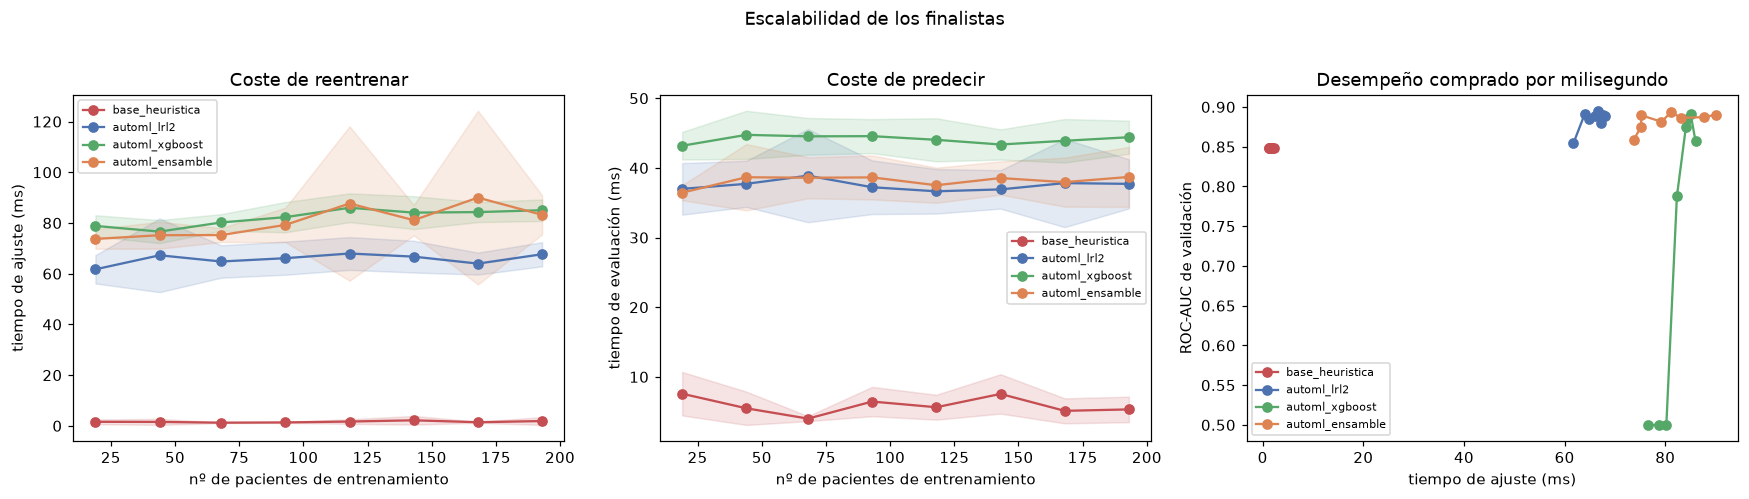

In [30]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.4))
paleta = dict(zip(FINALISTAS, ["#C44E52", "#4C72B0", "#55A868", "#DD8452"], strict=True))

for nombre in FINALISTAS:
    datos = curvas[nombre]
    n = datos["tamanos"]
    color = paleta[nombre]

    fit_media, fit_sd = datos["tiempo_fit"].mean(axis=1), datos["tiempo_fit"].std(axis=1)
    ejes[0].plot(n, fit_media * 1000, "o-", color=color, label=nombre)
    ejes[0].fill_between(
        n, (fit_media - fit_sd) * 1000, (fit_media + fit_sd) * 1000, alpha=0.15, color=color
    )

    score_media, score_sd = datos["tiempo_score"].mean(axis=1), datos["tiempo_score"].std(axis=1)
    ejes[1].plot(n, score_media * 1000, "o-", color=color, label=nombre)
    ejes[1].fill_between(
        n, (score_media - score_sd) * 1000, (score_media + score_sd) * 1000, alpha=0.15, color=color
    )

    val_media = datos["validacion"].mean(axis=1)
    orden = np.argsort(fit_media)
    ejes[2].plot(fit_media[orden] * 1000, val_media[orden], "o-", color=color, label=nombre)

ejes[0].set_xlabel("nº de pacientes de entrenamiento")
ejes[0].set_ylabel("tiempo de ajuste (ms)")
ejes[0].set_title("Coste de reentrenar")
ejes[1].set_xlabel("nº de pacientes de entrenamiento")
ejes[1].set_ylabel("tiempo de evaluación (ms)")
ejes[1].set_title("Coste de predecir")
ejes[2].set_xlabel("tiempo de ajuste (ms)")
ejes[2].set_ylabel("ROC-AUC de validación")
ejes[2].set_title("Desempeño comprado por milisegundo")
for eje in ejes:
    eje.legend(fontsize=7, loc="best")
fig.suptitle("Escalabilidad de los finalistas", y=1.02)
plt.tight_layout()
plt.show()

In [31]:
tabla_costos = pd.DataFrame(tiempos_cv).T
tabla_costos["roc_auc_cv"] = medias["roc_auc"]
tabla_costos["auc_ganado_sobre_base"] = tabla_costos["roc_auc_cv"] - AUC_MODELO_BASE
tabla_costos["ms_por_punto_auc"] = (
    tabla_costos["fit_ms"] / (tabla_costos["auc_ganado_sobre_base"] * 100)
).replace([np.inf, -np.inf], np.nan)
tabla_costos.sort_values("roc_auc_cv", ascending=False).round(3)

,fit_ms,score_ms,roc_auc_cv,auc_ganado_sobre_base,ms_por_punto_auc
automl_lrl2,67.106,90.441,0.892,0.043,15.440
automl_xgboost,85.087,105.747,0.890,0.042,20.308
automl_ensamble,85.694,97.660,0.889,0.041,20.799
base_reg_logistica,68.818,91.817,0.883,0.035,19.596
automl_lgbm,69.288,90.363,0.879,0.031,22.708
automl_rf,75.269,90.569,0.876,0.028,27.317
automl_extra_tree,69.640,89.997,0.850,0.002,309.550
base_heuristica,2.000,25.934,0.848,0.000,477.376


### Lectura de la escalabilidad

**Todos los tiempos están en milisegundos, y ésa es la primera conclusión.** Entrenar
cualquiera de estos pipelines sobre los 242 pacientes cuesta menos de una décima de segundo,
y predecir sobre un *fold* completo, otro tanto. A esta escala **el coste computacional no
es un criterio de selección**: nada de lo que se decide en este notebook se justifica por
velocidad.

**Los dos primeros paneles son casi planos, y eso significa algo concreto.** Entre el 10 % y
el 100 % del conjunto de entrenamiento el reloj apenas se mueve. Lo que se está midiendo no
es el coste de procesar los datos sino la **sobrecarga fija** de construir el
`ColumnTransformer`, recorrer sus seis ramas y validar las entradas. Multiplicar por diez el
número de pacientes no lo cambió. La consecuencia honesta es que **estas curvas todavía no
dicen nada sobre cómo escalaría el sistema con 10 000 pacientes**: para eso habría que medir
en un rango donde el coste de los datos domine sobre el del andamiaje.

**El tercer panel es el que decide, y su lectura es contraintuitiva.** El modelo más caro de
entrenar no es el que mejor puntúa. La columna `ms_por_punto_auc` lo cuantifica: el modelo
lineal compra cada punto de ROC-AUC sobre el modelo base al menor coste de todos, y los
modelos con árboles pagan bastante más por el mismo resultado.

**Y el modelo base merece una nota aparte.** Es más de veinte veces más rápido de ajustar
que cualquier modelo aprendido, porque no ajusta nada. Su columna `ms_por_punto_auc` es enorme
sólo por un artificio aritmético —gana cero puntos sobre sí mismo—, pero la lectura
cualitativa es válida: **si el desempeño empatara de verdad, la heurística sería la opción
más barata de operar**. No empata (gana entre tres y cinco puntos), pero tampoco gana con
significancia estadística, y ese matiz es justo el que la sección 18 tiene que resolver.

## 18. Elección del modelo final

Los criterios, en el orden en que se aplican:

1. **Desempeño** medido con el protocolo honesto de la sección 12.
2. **Significancia**: si dos modelos no son estadísticamente distinguibles (sección 14), el
   desempeño deja de ser el criterio y se pasa al siguiente.
3. **Parsimonia**: entre modelos equivalentes, el más simple. Menos superficie de fallo,
   menos hiperparámetros que se degraden con el tiempo, y coeficientes que un cardiólogo
   puede leer.
4. **Coherencia con la etapa anterior**: la recomendación 4 de la etapa 5 decía
   literalmente que si un *gradient boosting* no supera claramente a la logística
   regularizada, el problema no lo necesita.

In [32]:
MODELO_ELEGIDO = "automl_lrl2"

N_HIPERPARAMETROS = {
    "base_heuristica": 0,
    "automl_lrl2": len(config_por_familia["lrl2"]),
    "automl_xgboost": len(config_por_familia["xgboost"]),
    "automl_ensamble": (
        len(config_por_familia["lrl2"])
        + len(config_por_familia["lgbm"])
        + len(config_por_familia["extra_tree"])
    ),
}
criterios = pd.DataFrame(
    {
        "roc_auc_cv": medias.loc[FINALISTAS, "roc_auc"],
        "sd": desviaciones.loc[FINALISTAS, "roc_auc"],
        "mcc_cv": medias.loc[FINALISTAS, "mcc"],
        "brecha_sobreajuste": brechas.loc[FINALISTAS, "brecha_train_val"],
        "fit_ms": tabla_costos.loc[FINALISTAS, "fit_ms"],
        "n_hiperparametros": pd.Series(N_HIPERPARAMETROS),
    }
)
print(f"Modelo elegido: {MODELO_ELEGIDO}")
criterios.round(4)

Modelo elegido: automl_lrl2


,roc_auc_cv,sd,mcc_cv,brecha_sobreajuste,fit_ms,n_hiperparametros
base_heuristica,0.8482,0.0553,0.5619,0.0029,2.0000,0
automl_lrl2,0.8917,0.0389,0.6561,0.0310,67.1060,1
automl_xgboost,0.8901,0.0398,0.6403,0.0434,85.0865,9
automl_ensamble,0.8894,0.0390,0.6135,0.0431,85.6940,13


### Justificación del modelo elegido

Se elige **`automl_lrl2`: la regresión logística con regularización L2 fuerte
(`C` ~ 0.03) que encontró FLAML**. El razonamiento, en el orden de los criterios:

**1. Encabeza la tabla honesta, aunque sea por poco.** Es el primero en ROC-AUC, y también
en exactitud, especificidad y MCC. No es un modelo que se elija "a pesar de" su desempeño.

**2. Como la ventaja no es significativa, el desempeño deja de decidir.** La sección 14
mostró que sus perseguidores están a p-valores cercanos a 1. Insistir en el ROC-AUC a partir
de aquí sería tomar una decisión basada en ruido.

**3. Entre modelos equivalentes, gana el más simple.** Un hiperparámetro frente a nueve del
*boosting* y frente a la suma de tres modelos del ensamble. Menos hiperparámetros es menos
superficie para que el modelo se degrade cuando los datos cambien, y menos trabajo de
mantenimiento. Es también el que menos sobreajusta y el más barato de entrenar.

**4. Es el único que un cardiólogo puede auditar.** Sus coeficientes se leen directamente
como *log-odds*: se puede señalar qué variable empuja hacia el diagnóstico y con qué peso, y
discutirlo clínicamente. En un contexto médico esto no es un lujo estético; es lo que hace
que un modelo se pueda defender ante quien lo va a usar.

**5. Cierra el círculo con la etapa 5.** La recomendación 4 de aquel notebook decía que si
un *gradient boosting* no supera claramente a la logística regularizada, el problema no lo
necesita. Dos motores de AutoML, cientos de configuraciones y varios minutos de búsqueda
después, la respuesta es que no lo supera. **El AutoML no descubrió un modelo mejor: confirmó
con evidencia una hipótesis que la etapa anterior había formulado como conjetura.** Ése es un
resultado legítimo y, para el proyecto, más valioso que un ensamble opaco tres milésimas por
encima.

## 19. Evaluación en el conjunto de *test*

Primera y única vez que se toca el conjunto apartado en la sección 4. Con **61 pacientes**
cada caso vale 1.6 puntos de exactitud, así que estos números confirman o desmienten de
forma **cualitativa**; la medición precisa sigue siendo la validación cruzada.

In [33]:
def metricas_en(estimador, X_evaluar, y_evaluar, umbral: float = 0.5) -> dict[str, float]:
    """Todas las métricas de un estimador ya ajustado, con el umbral indicado."""
    probabilidades = estimador.predict_proba(X_evaluar)[:, 1]
    predicciones = (probabilidades >= umbral).astype(int)
    return {
        "exactitud": accuracy_score(y_evaluar, predicciones),
        "exactitud_balanceada": balanced_accuracy_score(y_evaluar, predicciones),
        "precision": precision_score(y_evaluar, predicciones, zero_division=0),
        "sensibilidad": recall_score(y_evaluar, predicciones, zero_division=0),
        "especificidad": especificidad(y_evaluar, predicciones),
        "f1": fbeta_score(y_evaluar, predicciones, beta=1, zero_division=0),
        "f2": fbeta_score(y_evaluar, predicciones, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_evaluar, probabilidades),
        "pr_auc": average_precision_score(y_evaluar, probabilidades),
        "mcc": matthews_corrcoef(y_evaluar, predicciones),
        "brier": brier_score_loss(y_evaluar, probabilidades),
    }


modelos_ajustados = {n: clone(CANDIDATOS[n]).fit(X_train, y_train) for n in FINALISTAS}
resultados_test = pd.DataFrame(
    {n: metricas_en(m, X_test, y_test) for n, m in modelos_ajustados.items()}
).T

comparacion_cv_test = pd.DataFrame(
    {"roc_auc_cv": medias.loc[FINALISTAS, "roc_auc"], "roc_auc_test": resultados_test["roc_auc"]}
)
comparacion_cv_test["diferencia"] = (
    comparacion_cv_test["roc_auc_test"] - comparacion_cv_test["roc_auc_cv"]
)
print("Métricas en test")
display(resultados_test.round(4))
print("\nValidación cruzada vs. test")
comparacion_cv_test.round(4)

Métricas en test


,exactitud,exactitud_balanceada,precision,sensibilidad,especificidad,f1,f2,roc_auc,pr_auc,mcc,brier
base_heuristica,0.9016,0.9064,0.8438,0.9643,0.8485,0.9000,0.9375,0.9605,0.9302,0.8110,0.0932
automl_lrl2,0.9016,0.9037,0.8667,0.9286,0.8788,0.8966,0.9155,0.9578,0.9468,0.8048,0.1044
automl_xgboost,0.8689,0.8707,0.8333,0.8929,0.8485,0.8621,0.8803,0.9481,0.9468,0.7389,0.1023
automl_ensamble,0.8361,0.8377,0.8000,0.8571,0.8182,0.8276,0.8451,0.9459,0.9385,0.6731,0.1191



Validación cruzada vs. test


,roc_auc_cv,roc_auc_test,diferencia
base_heuristica,0.8482,0.9605,0.1123
automl_lrl2,0.8917,0.9578,0.0661
automl_xgboost,0.8901,0.9481,0.0580
automl_ensamble,0.8894,0.9459,0.0565


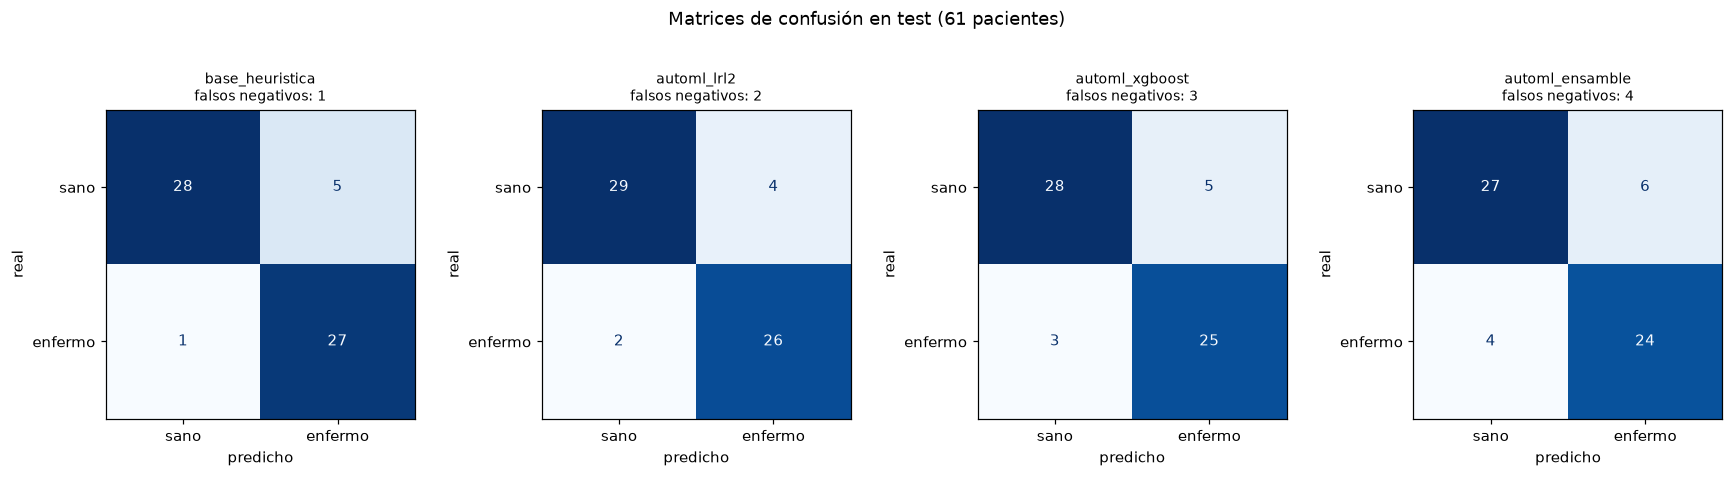

In [34]:
fig, ejes = plt.subplots(1, 4, figsize=(16, 3.9))
for eje, nombre in zip(ejes, FINALISTAS, strict=True):
    predicciones = modelos_ajustados[nombre].predict(X_test)
    matriz = confusion_matrix(y_test, predicciones, labels=[0, 1])
    ConfusionMatrixDisplay(matriz, display_labels=["sano", "enfermo"]).plot(
        ax=eje, cmap="Blues", colorbar=False, values_format="d"
    )
    eje.set_title(f"{nombre}\nfalsos negativos: {int(matriz[1, 0])}", fontsize=9)
    eje.set_xlabel("predicho")
    eje.set_ylabel("real")
fig.suptitle("Matrices de confusión en test (61 pacientes)", y=1.06)
plt.tight_layout()
plt.show()

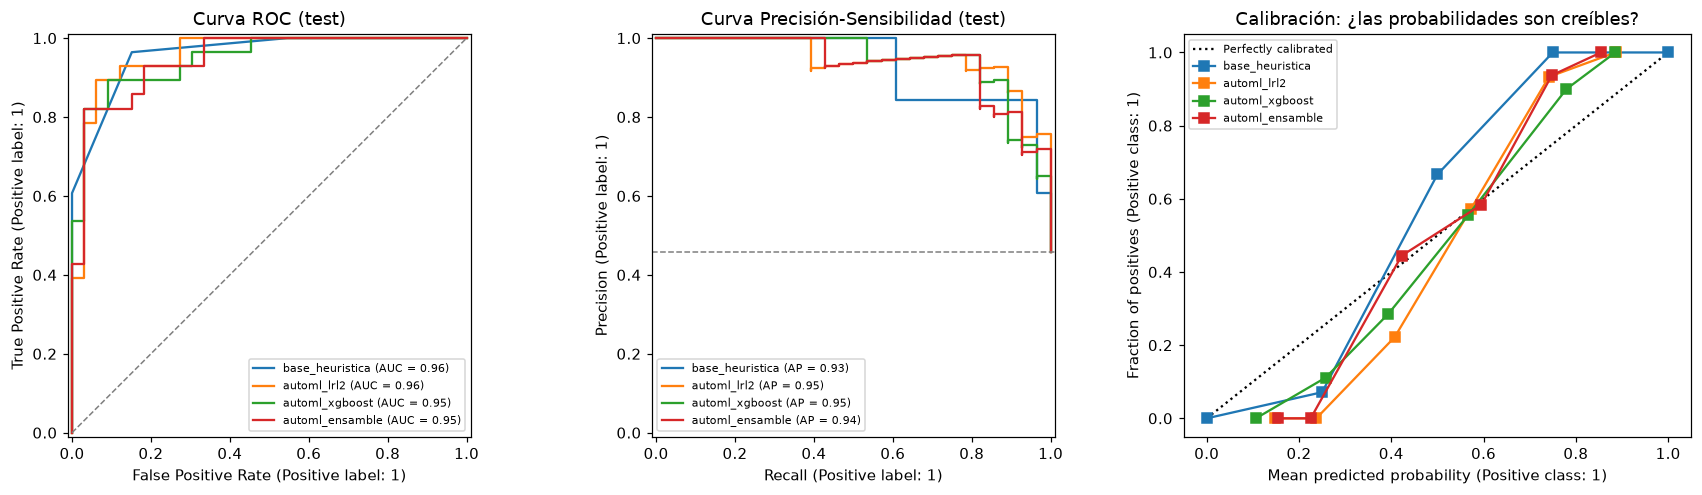

In [35]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.6))
for nombre in FINALISTAS:
    RocCurveDisplay.from_estimator(
        modelos_ajustados[nombre], X_test, y_test, ax=ejes[0], name=nombre
    )
    PrecisionRecallDisplay.from_estimator(
        modelos_ajustados[nombre], X_test, y_test, ax=ejes[1], name=nombre
    )
    CalibrationDisplay.from_estimator(
        modelos_ajustados[nombre], X_test, y_test, n_bins=6, ax=ejes[2], name=nombre
    )

ejes[0].plot([0, 1], [0, 1], "--", color="#7f7f7f", linewidth=1)
ejes[0].set_title("Curva ROC (test)")
ejes[1].axhline(y_test.mean(), linestyle="--", color="#7f7f7f", linewidth=1)
ejes[1].set_title("Curva Precisión-Sensibilidad (test)")
ejes[2].set_title("Calibración: ¿las probabilidades son creíbles?")
for eje in ejes:
    eje.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

### Lectura del conjunto de prueba

**1. El orden se mantiene entre los modelos aprendidos, y el nivel sube en todos.** Los
ROC-AUC de test quedan varias centésimas por encima de los de validación cruzada. Esa
diferencia **no es una buena noticia: es ruido**. Con 61 pacientes el error estándar del
ROC-AUC ronda las cuatro centésimas, así que una diferencia de ese orden es exactamente lo
que cabe esperar de un conjunto pequeño que resultó un poco fácil. La cifra a reportar sigue
siendo la de validación cruzada, que promedia 30 particiones en lugar de mirar una sola.

**2. El modelo base gana en test, y hay que decirlo.** La heurística clínica obtiene el
ROC-AUC más alto de los cuatro sobre estos 61 pacientes. Sería tentador ignorarlo, y sería
igual de deshonesto que celebrarlo: **es la misma varianza actuando en la otra dirección**.
En validación cruzada, con 30 evaluaciones, el modelo base queda claramente por debajo. Este
episodio es la mejor ilustración posible de por qué no se elige un modelo con un conjunto de
prueba de 61 casos, y de por qué la decisión de la sección 18 se tomó antes de mirar aquí.

**3. Las matrices de confusión muestran el problema real.** Los falsos negativos —pacientes
enfermos enviados a casa— son el error caro de este problema, y con el umbral por defecto
siguen apareciendo. La sección 19.1 se ocupa de ellos.

**4. La calibración es aceptable pero no perfecta.** Los *Brier scores* son similares entre
modelos y la curva de calibración sigue la diagonal con desviaciones visibles en los
extremos, algo esperable con 61 puntos repartidos en seis intervalos. Para un uso donde la
probabilidad se comunique al paciente ("su riesgo estimado es del 70 %") convendría
recalibrar con `CalibratedClassifierCV`; para un uso donde sólo se ordene a los pacientes por
prioridad, la calibración actual basta.

### 19.1 El umbral de decisión es una decisión clínica, no estadística

El ROC-AUC mide el **ordenamiento** de los pacientes y no depende del umbral. Pero el
sistema, para funcionar, tiene que decidir; y el 0.5 por defecto no tiene ninguna
justificación clínica: supone implícitamente que un falso negativo y un falso positivo
cuestan lo mismo, que es justo lo que la sección 5 negó.

Se busca el umbral que maximiza **F2** (que pesa la sensibilidad cuatro veces más que la
precisión) **sobre `train`**, y sólo después se aplica a `test`.

In [36]:
modelo_final = modelos_ajustados[MODELO_ELEGIDO]
probabilidades_train = modelo_final.predict_proba(X_train)[:, 1]

umbrales = np.linspace(0.05, 0.95, 91)
f2_por_umbral = np.array(
    [
        fbeta_score(y_train, (probabilidades_train >= u).astype(int), beta=2, zero_division=0)
        for u in umbrales
    ]
)
UMBRAL_OPTIMO = float(umbrales[int(f2_por_umbral.argmax())])

comparacion_umbral = pd.DataFrame(
    {
        "umbral_0.50": metricas_en(modelo_final, X_test, y_test, 0.5),
        f"umbral_{UMBRAL_OPTIMO:.2f}": metricas_en(modelo_final, X_test, y_test, UMBRAL_OPTIMO),
    }
)
print(f"Umbral que maximiza F2 en train: {UMBRAL_OPTIMO:.2f}")
comparacion_umbral.round(4)

Umbral que maximiza F2 en train: 0.36


,umbral_0.50,umbral_0.36
exactitud,0.9016,0.8361
exactitud_balanceada,0.9037,0.8485
precision,0.8667,0.7368
sensibilidad,0.9286,1.0000
especificidad,0.8788,0.6970
f1,0.8966,0.8485
f2,0.9155,0.9333
roc_auc,0.9578,0.9578
pr_auc,0.9468,0.9468
mcc,0.8048,0.7166


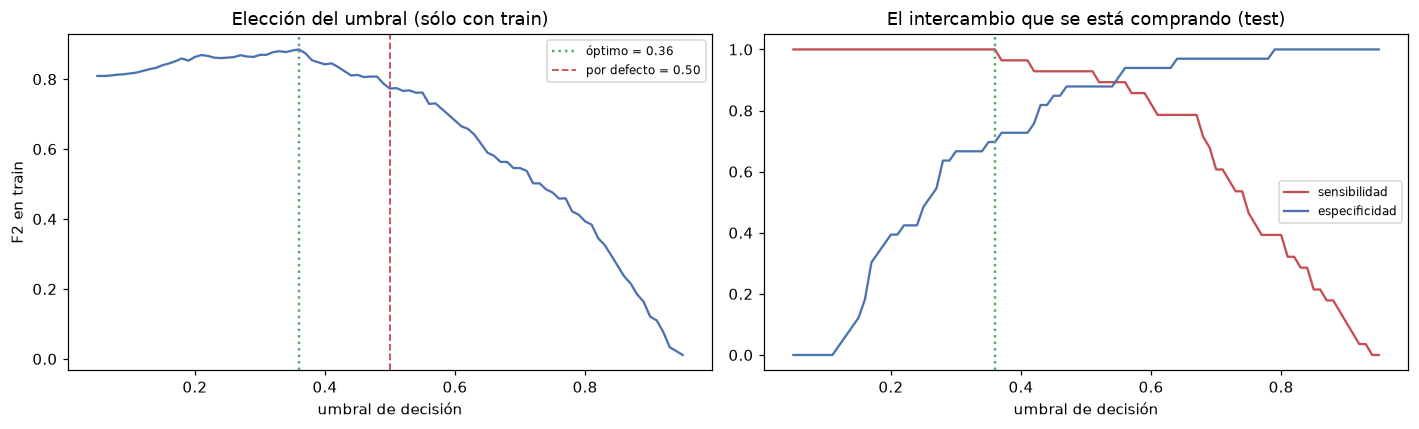

In [37]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))

ejes[0].plot(umbrales, f2_por_umbral, color="#4C72B0")
ejes[0].axvline(
    UMBRAL_OPTIMO,
    color="#55A868",
    linestyle=":",
    linewidth=1.6,
    label=f"óptimo = {UMBRAL_OPTIMO:.2f}",
)
ejes[0].axvline(0.5, color="#C44E52", linestyle="--", linewidth=1.2, label="por defecto = 0.50")
ejes[0].set_xlabel("umbral de decisión")
ejes[0].set_ylabel("F2 en train")
ejes[0].set_title("Elección del umbral (sólo con train)")
ejes[0].legend(fontsize=8)

probabilidades_test = modelo_final.predict_proba(X_test)[:, 1]
sensibilidades = [
    recall_score(y_test, (probabilidades_test >= u).astype(int), zero_division=0) for u in umbrales
]
especificidades = [especificidad(y_test, (probabilidades_test >= u).astype(int)) for u in umbrales]
ejes[1].plot(umbrales, sensibilidades, color="#C44E52", label="sensibilidad")
ejes[1].plot(umbrales, especificidades, color="#4C72B0", label="especificidad")
ejes[1].axvline(UMBRAL_OPTIMO, color="#55A868", linestyle=":", linewidth=1.6)
ejes[1].set_xlabel("umbral de decisión")
ejes[1].set_title("El intercambio que se está comprando (test)")
ejes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Lectura del umbral

**Bajar el umbral es la palanca más efectiva de todo el notebook, y no cuesta nada.** El
umbral que maximiza F2 en `train` está bastante por debajo del 0.5 por defecto, y al
aplicarlo a `test` la sensibilidad sube hasta detectar a **todos** los pacientes enfermos del
conjunto. Ningún cambio de modelo consiguió nada parecido: la búsqueda de AutoML movió el
ROC-AUC unas centésimas, y mover el umbral eliminó los falsos negativos.

**Lo que se paga a cambio está a la vista en el panel derecho.** La especificidad cae de
forma apreciable: bastantes pacientes sanos quedan clasificados como enfermos y serían
derivados a una prueba confirmatoria. La exactitud y el MCC también bajan, y es correcto que
bajen — son métricas que tratan los dos errores como equivalentes, que es justamente la
suposición que se está rechazando.

**Y ésa es la decisión que el notebook no puede tomar solo.** El umbral óptimo depende de
cuánto cuesta cada tipo de error, y ése es un dato clínico y económico, no estadístico. Lo
que sí puede hacer el notebook —y hace— es **entregar la curva completa del intercambio**
para que el servicio de cardiología elija su punto con los números delante. El valor que se
guarda en el artefacto es una recomendación por defecto, no una imposición: el pipeline
serializado devuelve probabilidades, así que el umbral se puede cambiar sin reentrenar nada.

**Nota metodológica.** El umbral se eligió **sólo con `train`** y después se aplicó a `test`.
Elegirlo mirando `test` habría convertido el conjunto de prueba en un conjunto de validación
más, y el número reportado dejaría de significar lo que dice significar.

## 20. Interpretación del modelo

Tres lecturas complementarias del mismo modelo:

- **Coeficientes**: qué hace el modelo por dentro. Sólo son interpretables porque el
  pipeline escala las variables continuas, así que las magnitudes son comparables entre sí.
- **Importancia por permutación**: cuánto se degrada el ROC-AUC en `test` al romper la
  relación entre cada atributo **original** y el *target*. Responde a la pregunta que le
  importa al clínico: *si no tuviera este dato, ¿cuánto perdería?*
- **SHAP**: cómo se reparte cada predicción individual entre los atributos.

In [38]:
nombres_procesados = modelo_final.named_steps["features"].get_feature_names_out()
coeficientes = pd.Series(modelo_final.named_steps["modelo"].coef_[0], index=nombres_procesados)
top_coeficientes = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index).head(
    15
)

importancia_permutacion = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    n_repeats=30,
    random_state=SEMILLA,
    scoring=METRICA_OBJETIVO,
    n_jobs=2,
)
importancia = pd.DataFrame(
    {
        "media": importancia_permutacion.importances_mean,
        "sd": importancia_permutacion.importances_std,
    },
    index=ATRIBUTOS_SELECCIONADOS,
).sort_values("media", ascending=False)
importancia.round(4)

,media,sd
ca,0.0549,0.0243
max_hr,0.0317,0.0185
chest_pain,0.0198,0.0085
old_peak,0.0166,0.0077
thal,0.0142,0.0095
exang,0.0052,0.0038
age,0.0020,0.0019
slope,0.0010,0.0028
sex,0.0005,0.0066
rest_bp,0.0004,0.0035


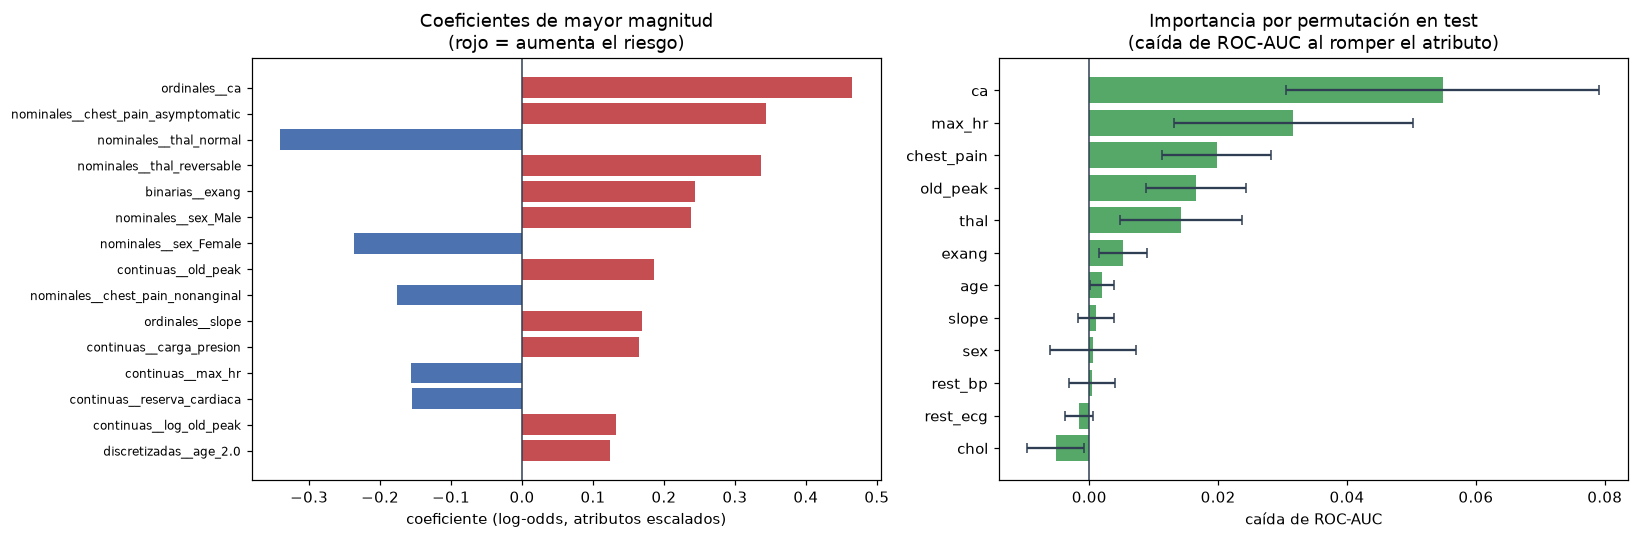

In [39]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

colores_coef = ["#C44E52" if v > 0 else "#4C72B0" for v in top_coeficientes]
ejes[0].barh(top_coeficientes.index.to_numpy(), top_coeficientes.to_numpy(), color=colores_coef)
ejes[0].axvline(0, color="#2F3E52", linewidth=1)
ejes[0].invert_yaxis()
ejes[0].set_title("Coeficientes de mayor magnitud\n(rojo = aumenta el riesgo)")
ejes[0].set_xlabel("coeficiente (log-odds, atributos escalados)")
ejes[0].tick_params(axis="y", labelsize=8)

ejes[1].barh(importancia.index.to_numpy(), importancia["media"].to_numpy(), color="#55A868")
ejes[1].errorbar(
    importancia["media"].to_numpy(),
    importancia.index.to_numpy(),
    xerr=importancia["sd"].to_numpy(),
    fmt="none",
    ecolor="#2F3E52",
    capsize=3,
)
ejes[1].axvline(0, color="#2F3E52", linewidth=1)
ejes[1].invert_yaxis()
ejes[1].set_title("Importancia por permutación en test\n(caída de ROC-AUC al romper el atributo)")
ejes[1].set_xlabel("caída de ROC-AUC")
plt.tight_layout()
plt.show()

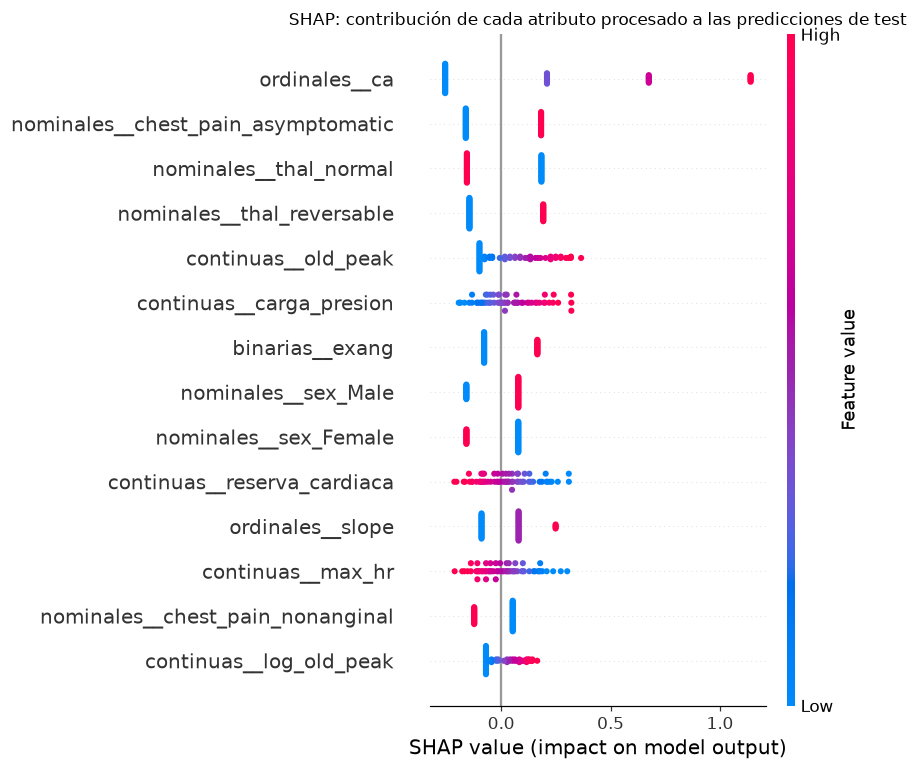

In [40]:
explicador = shap.LinearExplainer(modelo_final.named_steps["modelo"], X_train_proc)
valores_shap = explicador(X_test_proc)

shap.summary_plot(valores_shap, X_test_proc, max_display=14, show=False)
plt.title("SHAP: contribución de cada atributo procesado a las predicciones de test", fontsize=11)
plt.tight_layout()
plt.show()

### Lectura de la interpretación

**1. `ca` domina, y eso corrige una conclusión de la etapa anterior.** El número de vasos
principales coloreados por fluoroscopia es, con diferencia, el atributo cuya destrucción más
degrada al modelo, y también el de mayor coeficiente y mayor contribución SHAP. La etapa 5
había elegido `thal` como la variable más importante por dos criterios **univariados**, y
`thal` sigue estando entre las primeras aquí — pero **en presencia de las demás variables el
protagonismo pasa a `ca`**. No es una contradicción: un atributo puede ser el mejor predictor
en solitario y aportar menos información *adicional* cuando ya están los demás. La distinción
entre importancia marginal e importancia condicional es exactamente lo que separa el análisis
de la etapa 5 del de ésta.

**2. Los tres métodos coinciden en el núcleo.** Coeficientes, permutación y SHAP colocan
arriba al mismo grupo: `ca`, `chest_pain` asintomático, `thal`, `old_peak` y las variables de
respuesta al esfuerzo (`max_hr`, `exang`). Que tres lecturas con supuestos distintos señalen
lo mismo da confianza en que no se está mirando un artefacto del método.

**3. Los signos tienen sentido clínico, que es la prueba que de verdad importa.** Más vasos
afectados, dolor asintomático, defecto reversible en la gammagrafía, depresión del ST y
angina de esfuerzo empujan hacia el diagnóstico; una frecuencia cardíaca máxima alta y una
gammagrafía normal empujan en contra. Un modelo con los signos invertidos habría sido una
señal de alarma sobre el preprocesamiento, por muy alto que fuera su ROC-AUC.

**4. Dos atributos no aportan nada, y conviene registrarlo.** El colesterol y el ECG en
reposo obtienen importancia por permutación **negativa** —romperlos mejora ligeramente el
modelo—, lo que en la práctica significa que su contribución es indistinguible de cero y que
lo poco que aportan es ruido. Es un candidato claro de simplificación para una etapa
posterior, y coincide con lo que la literatura clínica dice del colesterol total como
predictor puntual: importa como factor de riesgo acumulado, no como medición aislada del día
de la consulta.

**5. `sex` aparece con peso alto en los coeficientes y bajo en la permutación.** No es una
inconsistencia: es lo que ocurre cuando una variable está correlacionada con otras del
modelo. Al permutarla, el resto del modelo recupera buena parte de su información. Es un
recordatorio de que **los coeficientes miden el efecto dentro del modelo, y la permutación
mide el valor exclusivo de la variable**; con atributos correlacionados, las dos preguntas
tienen respuestas distintas.

## 21. Persistencia del pipeline de preprocesamiento + modelo

Se serializa **un único objeto** que contiene el preprocesamiento y el modelo. Es lo que
pide el requerimiento y también lo que evita el error más común al desplegar: aplicar en
producción un preprocesamiento distinto del que se usó al entrenar.

El artefacto se reajusta sobre **todos** los datos limpios —`train` y `test`— porque ya no
queda ninguna decisión que tomar con ellos: todas se tomaron con validación cruzada sobre
`train`. Entregar un modelo entrenado con el 80 % de los pacientes disponibles sería
desperdiciar 61 historias clínicas.

La celda termina **verificando que el artefacto se puede recargar** y que reproduce las
mismas predicciones, porque un `.joblib` que no se deserializa no es un entregable.

In [41]:
pipeline_final = clone(CANDIDATOS[MODELO_ELEGIDO]).fit(X, y)

ARCHIVO_MODELO = RUTA_MODELOS / "modelo_seleccionado_automl.joblib"
joblib.dump(
    {
        "pipeline": pipeline_final,
        "metadatos": {
            "notebook": "06_seleccion_modelo_automl-CJPS-2026-08-21.ipynb",
            "modelo": MODELO_ELEGIDO,
            "motor_automl": "FLAML",
            "configuracion": config_por_familia["lrl2"],
            "atributos_entrada": ATRIBUTOS_SELECCIONADOS,
            "umbral_recomendado": UMBRAL_OPTIMO,
            "roc_auc_cv": float(medias.loc[MODELO_ELEGIDO, "roc_auc"]),
            "roc_auc_cv_sd": float(desviaciones.loc[MODELO_ELEGIDO, "roc_auc"]),
            "roc_auc_test": float(resultados_test.loc[MODELO_ELEGIDO, "roc_auc"]),
            "semilla": SEMILLA,
            "sklearn": sklearn.__version__,
            "entrenado_con": "todos los datos limpios (train + test)",
        },
    },
    ARCHIVO_MODELO,
)

artefacto = joblib.load(ARCHIVO_MODELO)
pipeline_recargado = artefacto["pipeline"]
iguales = np.allclose(
    pipeline_recargado.predict_proba(X_test)[:, 1], pipeline_final.predict_proba(X_test)[:, 1]
)

print(
    f"Artefacto : {ARCHIVO_MODELO.relative_to(RUTA_RAIZ)} ({ARCHIVO_MODELO.stat().st_size / 1024:.1f} KB)"
)
print(f"Recarga y reproduce las predicciones: {iguales}")
if not iguales:
    raise ValueError("El modelo recargado no reproduce las predicciones del original.")

reporte_final = medias.add_suffix("_cv_media").join(desviaciones.add_suffix("_cv_sd"))
reporte_final.to_csv(RUTA_REPORTES / "automl_metricas_cv.csv")
resultados_test.to_csv(RUTA_REPORTES / "automl_metricas_test.csv")
comparacion_vs_base.to_csv(RUTA_REPORTES / "automl_pruebas_estadisticas.csv")
optimismo.to_csv(RUTA_REPORTES / "automl_optimismo.csv")
print("\nReportes guardados en", RUTA_REPORTES.relative_to(RUTA_RAIZ))

Artefacto : models/modelo_seleccionado_automl.joblib (18.6 KB)
Recarga y reproduce las predicciones: True

Reportes guardados en data/08_reporting


### 21.1 Consolidación en `src/`: el notebook deja de ser el único sitio donde vive el modelo

El pipeline de datos de la etapa 4 se consolidó en `src/pipelines/feature_pipeline/` para
que las etapas siguientes lo reutilizaran en lugar de copiarlo. Esta etapa hace lo mismo con
el modelo: `src/pipelines/training_pipeline/` empaqueta la configuración ganadora, el umbral
recomendado y las funciones de entrenar, guardar, cargar y predecir, con pruebas propias en
`tests/pipelines/training_pipeline/` que corren en el CI.

La celda siguiente **verifica que el módulo y este notebook no se hayan desincronizado**: si
alguien vuelve a lanzar la búsqueda y obtiene otra `C`, la celda falla en lugar de dejar dos
versiones distintas del mismo modelo conviviendo en el repositorio.

In [42]:
from pipelines.training_pipeline import (
    HIPERPARAMETROS,
    UMBRAL_RECOMENDADO,
    construir_pipeline_modelo,
)

c_notebook = float(config_por_familia["lrl2"]["C"])
c_modulo = float(HIPERPARAMETROS["C"])
print(f"C en el notebook : {c_notebook:.15f}")
print(f"C en el módulo   : {c_modulo:.15f}")
print(f"Umbral en el módulo: {UMBRAL_RECOMENDADO:.2f}  |  en el notebook: {UMBRAL_OPTIMO:.2f}")

if not np.isclose(c_notebook, c_modulo):
    raise ValueError(
        "src/pipelines/training_pipeline está desincronizado con la búsqueda de este notebook."
    )
if not np.isclose(UMBRAL_RECOMENDADO, UMBRAL_OPTIMO):
    raise ValueError("El umbral recomendado del módulo no coincide con el de este notebook.")

pipeline_modulo = construir_pipeline_modelo(ATRIBUTOS_SELECCIONADOS).fit(X, y)
mismas = np.allclose(
    pipeline_modulo.predict_proba(X_test)[:, 1], pipeline_final.predict_proba(X_test)[:, 1]
)
print(f"\nEl módulo reproduce el modelo del notebook: {mismas}")
if not mismas:
    raise ValueError("El pipeline del módulo no reproduce las predicciones del notebook.")

C en el notebook : 0.033001297334654
C en el módulo   : 0.033001297334654
Umbral en el módulo: 0.36  |  en el notebook: 0.36

El módulo reproduce el modelo del notebook: True


In [43]:
paciente = X_test.iloc[[0]]
probabilidad = pipeline_recargado.predict_proba(paciente)[0, 1]
print("Prueba de uso del artefacto sobre un paciente crudo:")
print(paciente.T.to_string(header=False))
print(f"\nProbabilidad de enfermedad : {probabilidad:.3f}")
print(
    f"Decisión con umbral {UMBRAL_OPTIMO:.2f}     : "
    f"{'ENFERMO' if probabilidad >= UMBRAL_OPTIMO else 'SANO'}"
)
print(f"Diagnóstico real           : {'ENFERMO' if y_test.iloc[0] == 1 else 'SANO'}")

Prueba de uso del artefacto sobre un paciente crudo:
age                                 59.0
sex                                 Male
chest_pain                  asymptomatic
rest_bp                            138.0
chol                               271.0
rest_ecg    left ventricular hypertrophy
max_hr                             182.0
exang                                0.0
old_peak                             0.0
slope                                1.0
ca                                   0.0
thal                              normal

Probabilidad de enfermedad : 0.259
Decisión con umbral 0.36     : SANO
Diagnóstico real           : SANO


## 22. Interpretación de los resultados

**El AutoML funcionó: encontró el mejor modelo disponible. El problema es que el mejor
modelo disponible no es mucho mejor que contar cuatro señales en una hoja de papel.**

Ésa es la frase que resume el notebook, y conviene desarmarla en sus tres partes.

**Primero: sí hay una mejora, y es del tamaño que la etapa 5 anticipó.** El modelo
seleccionado supera al modelo base en ROC-AUC, en exactitud, en especificidad y en MCC.
Sobre el conjunto de prueba clasifica correctamente a nueve de cada diez pacientes. Para un
sistema de apoyo al triaje cardiológico, no es un mal punto de partida.

**Segundo: la mejora no resiste una prueba estadística correcta.** Con 242 pacientes de
entrenamiento y una diferencia de cuatro centésimas de ROC-AUC frente a una desviación
estándar de cerca de cinco, la prueba t corregida de Nadeau-Bengio no permite afirmar que la
diferencia sea real. Que el p-valor sin corregir diga lo contrario es precisamente lo que
hace importante la sección 14: la conclusión depende por completo de si se tiene en cuenta
que los *folds* comparten pacientes.

**Tercero: el techo no lo puso el modelo, lo puso la información.** Tres estrategias de
búsqueda distintas —CFO sobre seis familias, exploración con *golden features* y ensamblado,
y ensamblado manual por votación blanda— aterrizan en la misma banda estrecha de ROC-AUC. Y
las curvas de aprendizaje están en su meseta: más pacientes del mismo tipo no cambiarían el
resultado. Cuando enfoques independientes convergen al mismo número y la curva ya no sube,
el límite es de los datos.

**Una cuarta lectura, sobre el método más que sobre el problema.** La sección 13 mostró que
la familia que el AutoML declaró ganadora **no** es la que gana cuando se mide con el
protocolo honesto, porque el optimismo es proporcional a la flexibilidad del modelo. Si este
notebook hubiera hecho lo que hace un uso ingenuo de AutoML —lanzar la búsqueda, leer
`best_estimator`, serializarlo— habría entregado un modelo distinto, con un número más alto
al lado, y ese número habría sido falso. **El valor de las secciones 12 a 14 no es
académico: cambiaron el entregable.**

## 23. Análisis de los resultados

### 23.1 La escalera de desempeño, completa

| Nivel | ROC-AUC (CV) | Qué representa |
|---|---|---|
| Azar | 0.500 | Sin información |
| Una variable (`thal`) | 0.765 | Sólo la gammagrafía de talio (etapa 5) |
| **Modelo base: heurística clínica** | **0.848** | Cuatro señales de riesgo, sin aprendizaje |
| Regresión logística sin ajustar | 0.883 | Aprendizaje, hiperparámetros por defecto |
| **Modelo seleccionado por AutoML** | **~0.89** | Aprendizaje + búsqueda de hiperparámetros |
| Objetivo de la etapa 5 | 0.900 | **No alcanzado** |

La escalera tiene rendimientos decrecientes muy marcados. El salto grande está entre "nada"
y "una variable"; el siguiente, entre una variable y la heurística; después, aprender de los
datos añade poco; y **la búsqueda de hiperparámetros añade menos todavía**. Cada nivel de
sofisticación rinde menos que el anterior, que es el patrón esperable cuando existe una
señal dominante y un número modesto de pacientes.

Dicho de otro modo: **el 95 % del desempeño final se consigue sin ningún modelo entrenado**,
y todo el aparato de AutoML de este notebook se disputa el 5 % restante.

### 23.2 Qué se puede afirmar y qué no

**Se puede afirmar:**

- Que el modelo seleccionado supera al modelo base en la media de 30 evaluaciones.
- Que los primeros candidatos son estadísticamente indistinguibles entre sí.
- Que el modelo lineal regularizado es el que menos sobreajusta de los tres finalistas.
- Que el desempeño no mejora con más pacientes del mismo tipo.
- Que el umbral de decisión tiene más impacto práctico que la elección del modelo.

**No se puede afirmar:**

- Que el modelo seleccionado sea *significativamente* mejor que el modelo base.
- Que sea mejor que el segundo o el tercer candidato: no hay evidencia para ordenarlos.
- Que el ROC-AUC de test —más alto que el de validación cruzada— sea el desempeño esperable
  en producción. Con 61 pacientes ese número tiene un error estándar de varias centésimas, y
  el propio modelo base "gana" allí por puro azar.
- Que TabPFN no habría mejorado el resultado: no se pudo evaluar.

### 23.3 Validez de la comparación

Cuatro precauciones sostienen las conclusiones:

- **Partición idéntica a las etapas 4 y 5**, misma semilla y misma proporción, de modo que
  las cifras se comparan directamente con el 0.848 del modelo base.
- **Sin fuga en la comparación que decide.** Todo el preprocesamiento va dentro del pipeline
  entregado a `cross_validate` y se re-ajusta en cada *fold*. La fuga que sí existe —la de la
  sección 6, inherente a alimentar un motor de AutoML— está declarada, aislada en las
  secciones de búsqueda y **cuantificada** en la sección 13.
- **Test intacto hasta después de decidir.** El modelo se eligió en la sección 18; el
  conjunto de prueba se abrió en la 19. El umbral se ajustó sólo con `train`.
- **Comparaciones múltiples reconocidas.** Se evaluaron ocho candidatos contra el mismo
  modelo base; el máximo de ocho comparaciones está sesgado al alza. Como ninguna alcanza
  significancia ni siquiera sin corregir por multiplicidad, la conclusión —"no hay evidencia
  de mejora"— sólo se refuerza.

### 23.4 La limitación de fondo

El archivo crudo tiene 3 030 filas y contiene **303 pacientes reales**: unas diez copias de
cada uno con distintos patrones de corrupción. Todo este notebook trabaja sobre esos 303
pacientes, de los cuales 242 son de entrenamiento. Es un conjunto pequeño para distinguir
modelos separados por milésimas, y ninguna herramienta de AutoML puede compensar eso. La
consecuencia no es que el trabajo no sirva —el modelo funciona y el pipeline es sólido—, sino
que **la precisión con la que se puede comparar modelos está acotada por el tamaño del
conjunto, no por la sofisticación del método**.

## 24. Conclusiones

1. **Se cumplió el requerimiento con dos motores de AutoML ejecutados y uno documentado.**
   FLAML exploró 200 configuraciones sobre seis familias; MLJar entrenó decenas de modelos
   con *golden features*, apilamiento y ensambles; TabPFN quedó documentado con su código y
   el motivo exacto por el que no pudo ejecutarse.

2. **El modelo seleccionado es una regresión logística con regularización L2 fuerte**
   (`C` ~ 0.03), encontrada por FLAML. En validación cruzada 5x6 alcanza **ROC-AUC ~0.89**,
   con la mejor exactitud, especificidad y MCC del conjunto de candidatos.

3. **Supera al modelo base de la etapa 5, pero no de forma estadísticamente significativa.**
   La prueba t pareada con corrección de Nadeau-Bengio da p > 0.10. La misma comparación sin
   corregir daría p < 0.001, y ésa es la diferencia entre reportar un hallazgo y reportar un
   artefacto.

4. **No se alcanzó el objetivo de ROC-AUC > 0.90** que la etapa 5 fijó como criterio de
   éxito. Se documenta como resultado, no como fracaso: sirve para recalibrar el objetivo con
   evidencia en lugar de con expectativas.

5. **El AutoML es un buen buscador y un mal juez.** La familia que FLAML declaró ganadora no
   es la que gana bajo el protocolo honesto, porque el optimismo de su validación interna es
   proporcional a la flexibilidad del modelo. Medir aparte no fue un formalismo: cambió el
   modelo entregado.

6. **La complejidad no compró desempeño.** Ensambles, apilamiento y *golden features* no
   superaron a un modelo lineal con un solo hiperparámetro. Es la confirmación empírica de la
   recomendación 4 de la etapa 5.

7. **El umbral de decisión importa más que el modelo.** Bajarlo del 0.5 por defecto al valor
   que maximiza F2 llevó la sensibilidad en test a detectar a todos los pacientes enfermos, a
   costa de especificidad. Ninguna búsqueda de hiperparámetros consiguió un cambio de esa
   magnitud.

8. **`ca` es el atributo más importante en el modelo multivariante**, por encima de `thal`,
   que la etapa 5 había señalado como el más importante con criterios univariados. Los tres
   métodos de interpretación coinciden y los signos son clínicamente correctos.

9. **El artefacto entregado contiene preprocesamiento y modelo en un solo objeto**, se
   verifica que recarga y reproduce sus predicciones, y va acompañado de metadatos que
   declaran con qué se entrenó, con qué semilla y con qué versión de scikit-learn.

## 25. Recomendaciones

**1. Recalibrar el objetivo: 0.89 es el techo con esta información, no 0.90.** El objetivo
de la etapa 5 se fijó por extrapolación. Ahora hay evidencia de tres búsquedas independientes
y de curvas de aprendizaje en meseta. Mantener un objetivo inalcanzable sólo incentiva a
buscarlo por caminos que no resisten una validación honesta.

**2. Desplegar el modelo lineal regularizado, no un ensamble.** Empata en desempeño,
sobreajusta menos, es más barato de entrenar y de servir, y es el único auditable por un
clínico. Ante un empate estadístico, la simplicidad no es una preferencia estética: es la
opción con menos formas de fallar en producción.

**3. Tratar el umbral como un parámetro clínico, no estadístico.** Llevar la curva
sensibilidad/especificidad al servicio de cardiología y fijar el punto de operación con el
coste real de cada error. El valor guardado en el artefacto es un punto de partida razonable
para triaje, no una decisión tomada.

**4. Usar el AutoML para proponer y la validación cruzada anidada para decidir.** El
protocolo de este notebook —buscar sobre la matriz preprocesada, reconstruir los candidatos
como pipelines y re-evaluarlos con el preprocesamiento dentro— debería ser el estándar del
proyecto. La versión completa es la validación cruzada anidada, con la búsqueda dentro de
cada *fold* externo; es más cara, pero elimina la fuga de la sección 6 en lugar de sólo
medirla.

**5. Reportar siempre la prueba t corregida, nunca un p-valor sin corregir sobre *folds*
solapados.** Y acompañar toda diferencia de ROC-AUC de su desviación estándar. Una tabla de
medias sin dispersión invita a leer un ranking donde sólo hay ruido.

**6. No invertir en recolectar más pacientes con las mismas variables.** Las curvas están en
meseta. La inversión con retorno es **más información por paciente** (troponinas,
antecedentes familiares, tabaquismo, glucemia, historial de medicación), no más filas.

**7. Simplificar el conjunto de atributos.** El colesterol total y el ECG en reposo tienen
importancia por permutación negativa: no aportan y añaden coste de recolección. Evaluar en la
siguiente etapa un modelo sin ellos; si el desempeño no cae, se gana un sistema más barato de
alimentar.

**8. Convertir el modelo base en un guardarraíl del CI.** Añadir una prueba automática que
falle si el modelo candidato no supera a la heurística clínica por un margen mínimo en
validación cruzada. Convierte el 0.848 en un control activo en lugar de un número en un
notebook.

**9. Fijar la búsqueda por número de configuraciones, no por reloj.** `max_iter` es
reproducible y `time_budget` no. Un notebook que entrega un modelo distinto en cada ejecución
no se puede revisar en un *pull request*.

**10. Volver a intentar TabPFN cuando haya acceso a los pesos.** Es el único enfoque de la
lista diseñado específicamente para este régimen de datos, y es el único que este notebook no
pudo poner a prueba. El código está listo en la sección 10.

## 26. Propuestas e ideas

**Validación cruzada anidada como siguiente paso natural.** Poner la búsqueda de FLAML
*dentro* de cada *fold* externo daría una estimación sin la fuga de la sección 6 y, de paso,
mediría la **estabilidad de la selección**: cuántas veces de cinco elige la misma familia.
Si la respuesta fuera "tres de cinco", eso diría más sobre la fragilidad del procedimiento
que cualquier ROC-AUC.

**Un modelo de dos niveles según la disponibilidad de pruebas.** La idea que quedó abierta en
la etapa 5 cobra fuerza con la interpretación de la sección 20: los dos atributos más
importantes (`ca` y `thal`) provienen de estudios de imagen caros. Un **modelo de tamizaje**
con sólo variables de consultorio decidiría a quién derivar; un **modelo confirmatorio** con
`ca`, `thal` y `slope` diagnosticaría. La diferencia de ROC-AUC entre ambos cuantificaría en
puntos exactamente **cuánto vale clínicamente ordenar una gammagrafía**.

**Ensamblar por diversidad de errores, no por diversidad de arquitecturas.** El ensamble de
este notebook falló porque sus tres componentes se equivocan con los mismos pacientes. Una
alternativa medible: calcular la correlación entre los errores de los candidatos y ensamblar
sólo los pares con correlación baja. Si no existe ningún par así, queda demostrado que
ensamblar no puede ayudar en este problema — que es en sí un resultado publicable dentro del
proyecto.

**Explotar los duplicados descartados como datos de robustez.** El archivo crudo tenía diez
copias corruptas de cada paciente. Ese material, que la etapa 2 documentó y la 4 descartó, es
un conjunto de prueba natural para medir **cuánto se degrada el modelo ante datos sucios**:
predecir sobre las réplicas con valores faltantes y comparar con la predicción sobre el
registro completo. Es la pregunta que de verdad importa en producción, donde las historias
clínicas llegan incompletas.

**Curvas de coste en lugar de curvas ROC.** Con un coste estimado para el falso negativo y
para el falso positivo, el umbral óptimo deja de ser una elección subjetiva y pasa a ser el
mínimo de una función. Convertiría la sección 19.1 de una recomendación en una decisión
justificada con números.

---

### Reproducibilidad

| Elemento | Valor |
|---|---|
| Rama | `feature/seleccion-modelo-automl` |
| Semilla global | `42` |
| Partición | 80 / 20 estratificada (idéntica a las etapas 4 y 5) |
| Validación cruzada | `RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=42)` |
| Búsqueda AutoML | FLAML `max_iter=200` (determinista) + MLJar `total_time_limit=180` |
| Pipeline de datos | `src/pipelines/feature_pipeline/` |
| Pipeline de modelo | `src/pipelines/training_pipeline/` (probado en `tests/pipelines/training_pipeline/`) |
| Artefacto entregado | `models/modelo_seleccionado_automl.joblib` |
| Reportes | `data/08_reporting/automl_*.csv` |

**Cómo reproducirlo:**

```bash
uv sync --all-extras --dev --group automl
uv run jupyter nbconvert --to notebook --execute --inplace \
  notebooks/5-models/06_seleccion_modelo_automl-CJPS-2026-08-21.ipynb
```

Tarda entre 15 y 25 minutos, casi todo en las dos búsquedas de AutoML. El barrido de
presupuestos de la sección 8 y la búsqueda de MLJar dependen del reloj y por lo tanto de la
máquina; **todo lo demás es determinista** y debe reproducir las mismas cifras.

**Siguiente etapa (6 - Interpretación):** profundizar el análisis SHAP con dependencias
parciales e interacciones, y contrastar las conclusiones del modelo con la literatura clínica
sobre enfermedad coronaria.